In [2]:
source("C:/Users/daiki/OneDrive/Documentos/USP/Iniciação Científica/Função/funcoes_final_nao_proporcionais.R", local = FALSE, echo = FALSE, print.eval = FALSE)

pacote 'survminer' desempacotado com sucesso e somas MD5 verificadas

Os pacotes binários baixados estão em
	C:\Users\daiki\AppData\Local\Temp\RtmpcdfkMY\downloaded_packages


Warning message:
"pacote 'Rlab' foi compilado no R versão 4.4.3"

Anexando pacote: 'survival'


O seguinte objeto é mascarado por 'package:Rlab':

    cancer


Carregando pacotes exigidos: ggpubr


Anexando pacote: 'survminer'


O seguinte objeto é mascarado por 'package:survival':

    myeloma




In [3]:
## =========================================================================================================================== ###
## grafico de poder empirico x tamanho amostral - MULTIPLOS TESTES NUM UNICO PLOT
## Por padrao roda os 4 testes pedidos: Log-Rank G(0,0), Wilcoxon G(1,0), G(0,1) e G(1,1)
## mas aceita qualquer lista de pares (rho, eta) em 'testes'.
simulacao_amostral_empirica_4testes <- function(n_sim = 200,
                                                 ns = seq(20, 100, by = 20),
                                                 testes = list(
                                                   c(rho = 0, eta = 0),  # Log-Rank
                                                   c(rho = 1, eta = 0),  # Wilcoxon
                                                   c(rho = 0, eta = 1),
                                                   c(rho = 1, eta = 1)
                                                 ),
                                                 alpha = 0.05) {

  n_testes <- length(testes)
  nomes_testes <- sapply(testes, function(tt) paste0("G(", tt["rho"], ",", tt["eta"], ")"))

  resultados <- data.frame()
  z_critico <- qnorm(1 - alpha / 2)

  for (n_atual in ns) {
    cat("Processando n =", n_atual, "\n")

    rejeicoes <- rep(0, n_testes)

    censura_exp_acum <- numeric(n_sim)
    censura_ctrl_acum <- numeric(n_sim)

    n <<- n_atual

    for (i in 1:n_sim) {

      dados <<- exemplo(distribuicao, n, pi,
                        parametro_falha_experimental, parametro_falha_controle,
                        parametro_censura_experimental, parametro_censura_controle,
                        shape_falha_experimental_weibull, shape_censura_experimental_weibull,
                        shape_falha_controle_weibull, shape_censura_controle_weibull,
                        sdlog_falha_experimental, sdlog_censura_experimental,
                        sdlog_falha_controle, sdlog_censura_controle, individual = "nao")

      # roda cada teste da lista sobre a MESMA base gerada (comparacao pareada)
      for (k in 1:n_testes) {
        rho_k <- testes[[k]]["rho"]
        eta_k <- testes[[k]]["eta"]
        if (abs(T(rho_k, eta_k)) > z_critico) {
          rejeicoes[k] <- rejeicoes[k] + 1
        }
      }

      censura_exp_acum[i] <- mean(dados$delta[dados$grupo == 'A'] == 0)
      censura_ctrl_acum[i] <- mean(dados$delta[dados$grupo == 'B'] == 0)
    }

    cat(sprintf("\n=== Relatorio | n = %d ===\n", n_atual))
    cat(sprintf("Grupo Experimental (A) - Censura Media: %.1f%%\n", mean(censura_exp_acum) * 100))
    cat(sprintf("Grupo Controle (B) - Censura Media: %.1f%%\n", mean(censura_ctrl_acum) * 100))
    cat("=====================================\n")

    for (k in 1:n_testes) {
      resultados <- rbind(resultados, data.frame(
        n = n_atual,
        Poder = rejeicoes[k] / n_sim,
        Teste = nomes_testes[k]
      ))
    }
  }

  # mantem a ordem dos testes na legenda igual a ordem em que foram passados
  resultados$Teste <- factor(resultados$Teste, levels = nomes_testes)

  cores_padrao <- c("#D55E00", "#0072B2", "#009E73", "#CC79A7", "#E69F00", "#56B4E9")
  cores <- setNames(cores_padrao[seq_len(n_testes)], nomes_testes)

  # Grafico de Poder Empirico com todos os testes juntos
 # g <- ggplot(resultados, aes(x = n, y = Poder, color = Teste)) +
 #   geom_line(linewidth = 1.2) +
 #   geom_point(size = 3) +
 #   geom_hline(yintercept = alpha, linetype = "dashed", color = "gray40") +
 #   scale_color_manual(values = cores) +
 #   scale_y_continuous(limits = c(0, 1), breaks = seq(0, 1, 0.1)) +
 #   scale_x_continuous(breaks = ns) +
 #   labs(
 #     title = "Poder Empirico: Log-Rank, Wilcoxon, G(0,1) e G(1,1)",
 #     subtitle = paste("Simulacao de Monte Carlo (", n_sim, " repeticoes)"),
 #     x = "Tamanho Amostral (n)",
 #     y = "Poder (Taxa de Rejeicao)",
 #     color = "Teste"
 #   ) +
 #   theme_minimal(base_size = 14) +
 #   theme(
 #     legend.position = "bottom",
 #     plot.title = element_text(face = "bold", hjust = 0.5),
 #     axis.text.x = element_text(angle = 45, hjust = 1)
 #   )

 #   g <- ggplot(resultados, aes(x = n, y = Poder, color = Teste)) +
 #   geom_smooth(method = "loess", se = FALSE, linewidth = 1.2, span = 1) +
 #   scale_y_continuous(limits = c(0, 1), breaks = seq(0, 1, 0.1)) +
 #   labs(title = "Poder Empírico por Peso",
 #        subtitle = paste("Monte Carlo (", n_sim, "repetições)"),
 #        x = "Tamanho Amostral (n)", y = "Poder (Taxa de Rejeição)") +
 #   theme_minimal()

 # print(g)
  return(resultados)  # retorna o dataframe (n, Poder, Teste) para analise adicional
}

In [29]:
### =========================================== APLICACAO ======================= ###
n <- 300
pi <- 0.5

# Ajuste para riscos não proporcionais
distribuicao <- "weibull"

# --- GRUPO EXPERIMENTAL (A) --- (shape e scale inalterados)
shape_falha_experimental_weibull <- 0.5
parametro_falha_experimental <- 31.22
parametro_censura_experimental <- 50
shape_censura_experimental_weibull <- shape_falha_experimental_weibull

# --- GRUPO CONTROLE (B) --- (shape inalterado, scale reduzido para cruzar mais cedo)
shape_falha_controle_weibull <- 2.5
parametro_falha_controle <- 17.37  # <- alterado de 4.0 para 1.414
parametro_censura_controle <- 50  # considere reduzir também, ver nota abaixo
shape_censura_controle_weibull <- shape_falha_controle_weibull

In [30]:
distribuicao = "weibull"
pi = 0.5
parametro_falha_experimental = 80.616241   # calculado
parametro_falha_controle     = 70          # como voce passou
parametro_censura_experimental = 183
parametro_censura_controle     = 183
shape_falha_experimental_weibull = 1.5
shape_falha_controle_weibull     = 0.6

In [33]:
dados <- exemplo(distribuicao, n, pi, 
                    parametro_falha_experimental, parametro_falha_controle, 
                    parametro_censura_experimental, parametro_censura_controle,
                    shape_falha_experimental_weibull, shape_censura_experimental_weibull, 
                    shape_falha_controle_weibull, shape_censura_controle_weibull, 
                    sdlog_falha_experimental, sdlog_censura_experimental, 
                    sdlog_falha_controle, sdlog_censura_controle)

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Ignoring unknown labels:
• colour : "Strata"


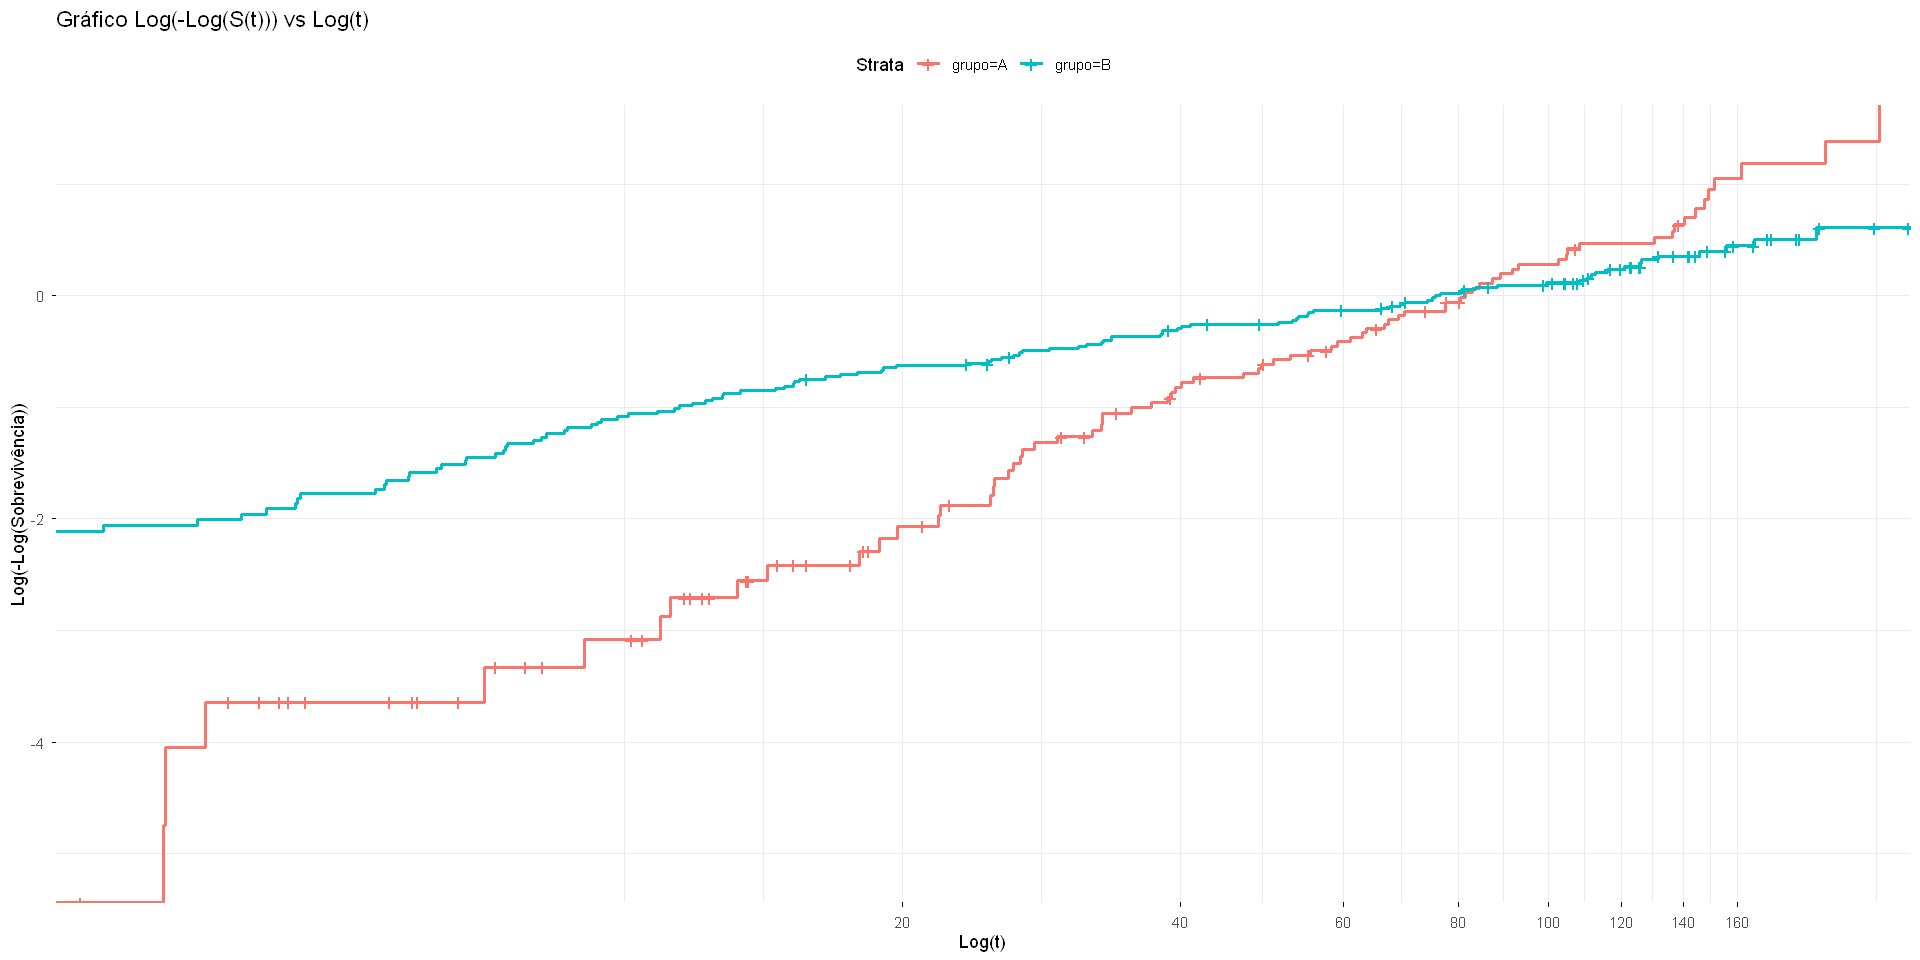

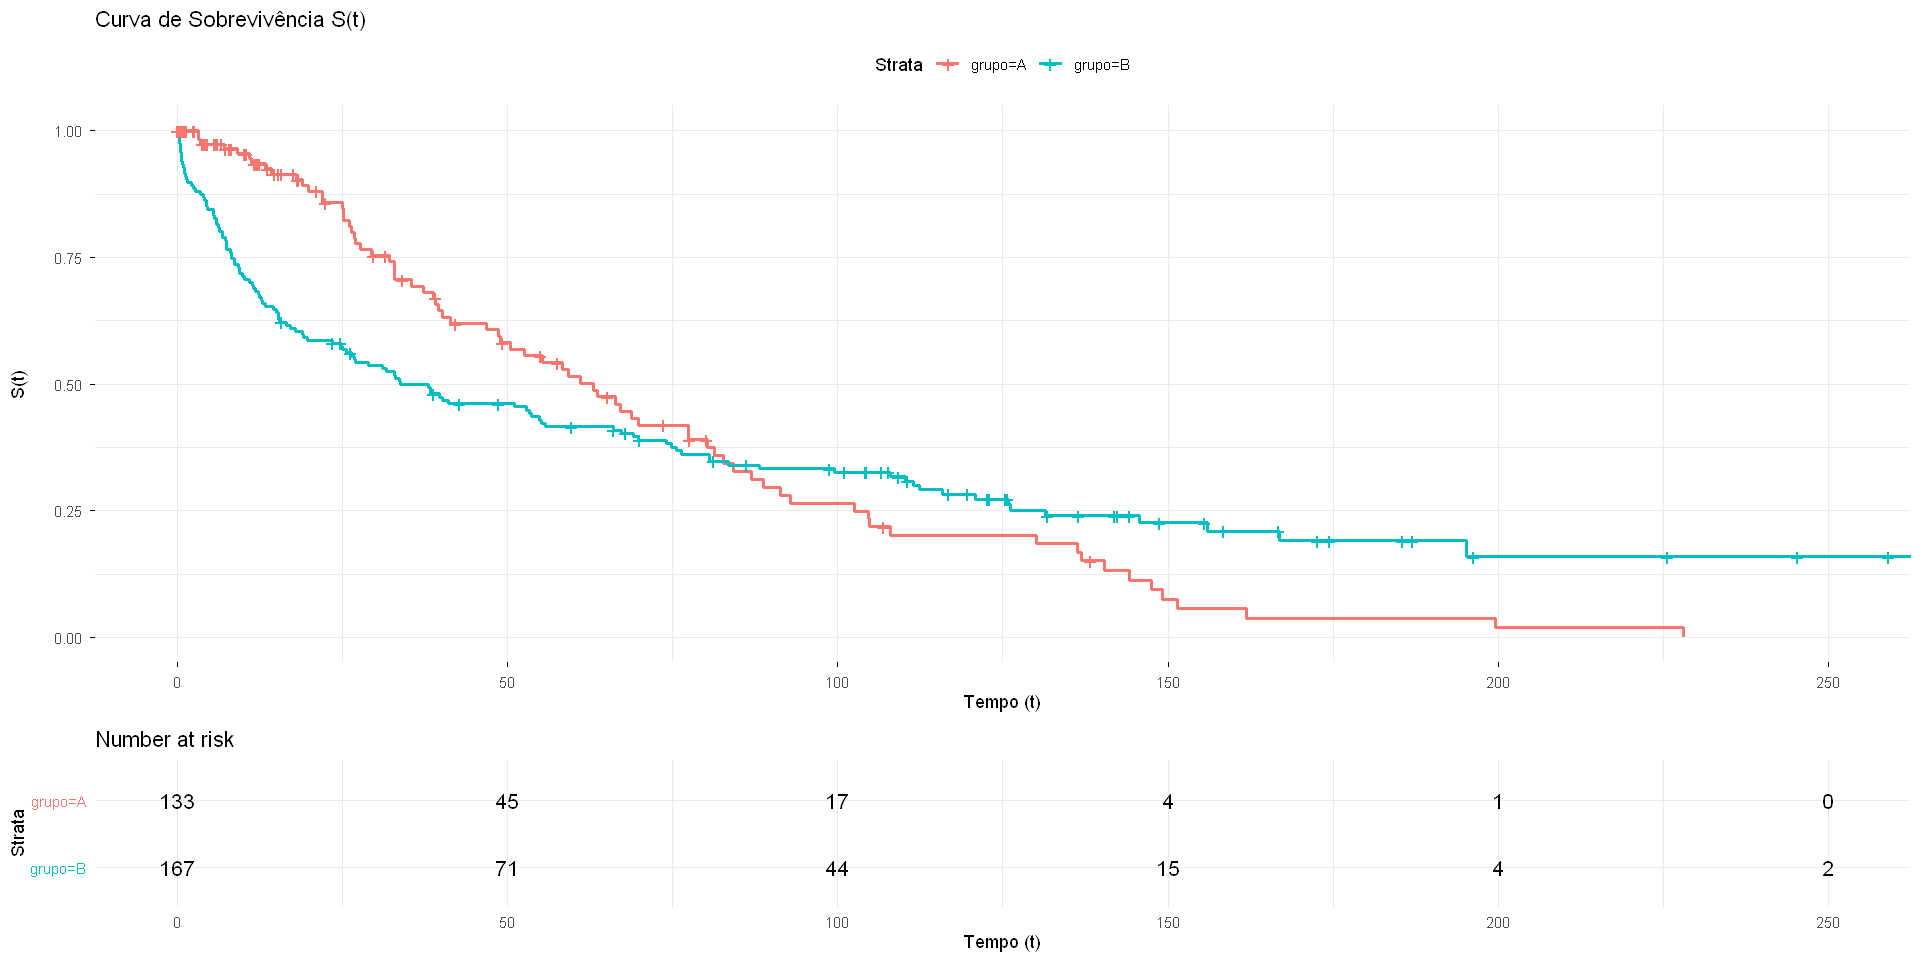

In [60]:
curva <- survfit(Surv(z, delta) ~ grupo, data = dados)
g <- ggsurvplot(curva,
                fun = "cloglog",
                ggtheme = theme_minimal(),
                title = "Gráfico Log(-Log(S(t))) vs Log(t)",
                xlab = "Log(t)",
                ylab = "Log(-Log(Sobrevivência))")

g$plot +
  scale_x_log10(breaks = c(1, 20, 40, 60, 80, 100, 120, 140, 160,300)) +
  coord_cartesian(xlim = c(3, 200))
ggsurvplot(
  curva,
  conf.int = FALSE,
  risk.table = TRUE,
  ggtheme = theme_minimal(),
  title = "Curva de Sobrevivência S(t)",
  xlab = "Tempo (t)",
  ylab = "S(t)"
)



   strata   median    lower    upper
1 grupo=A 70.55005 59.05109 86.27071
2 grupo=B 49.66382 29.37760 64.27338


Ignoring unknown labels:
• colour : "Strata"
Ignoring unknown labels:
• colour : "Strata"


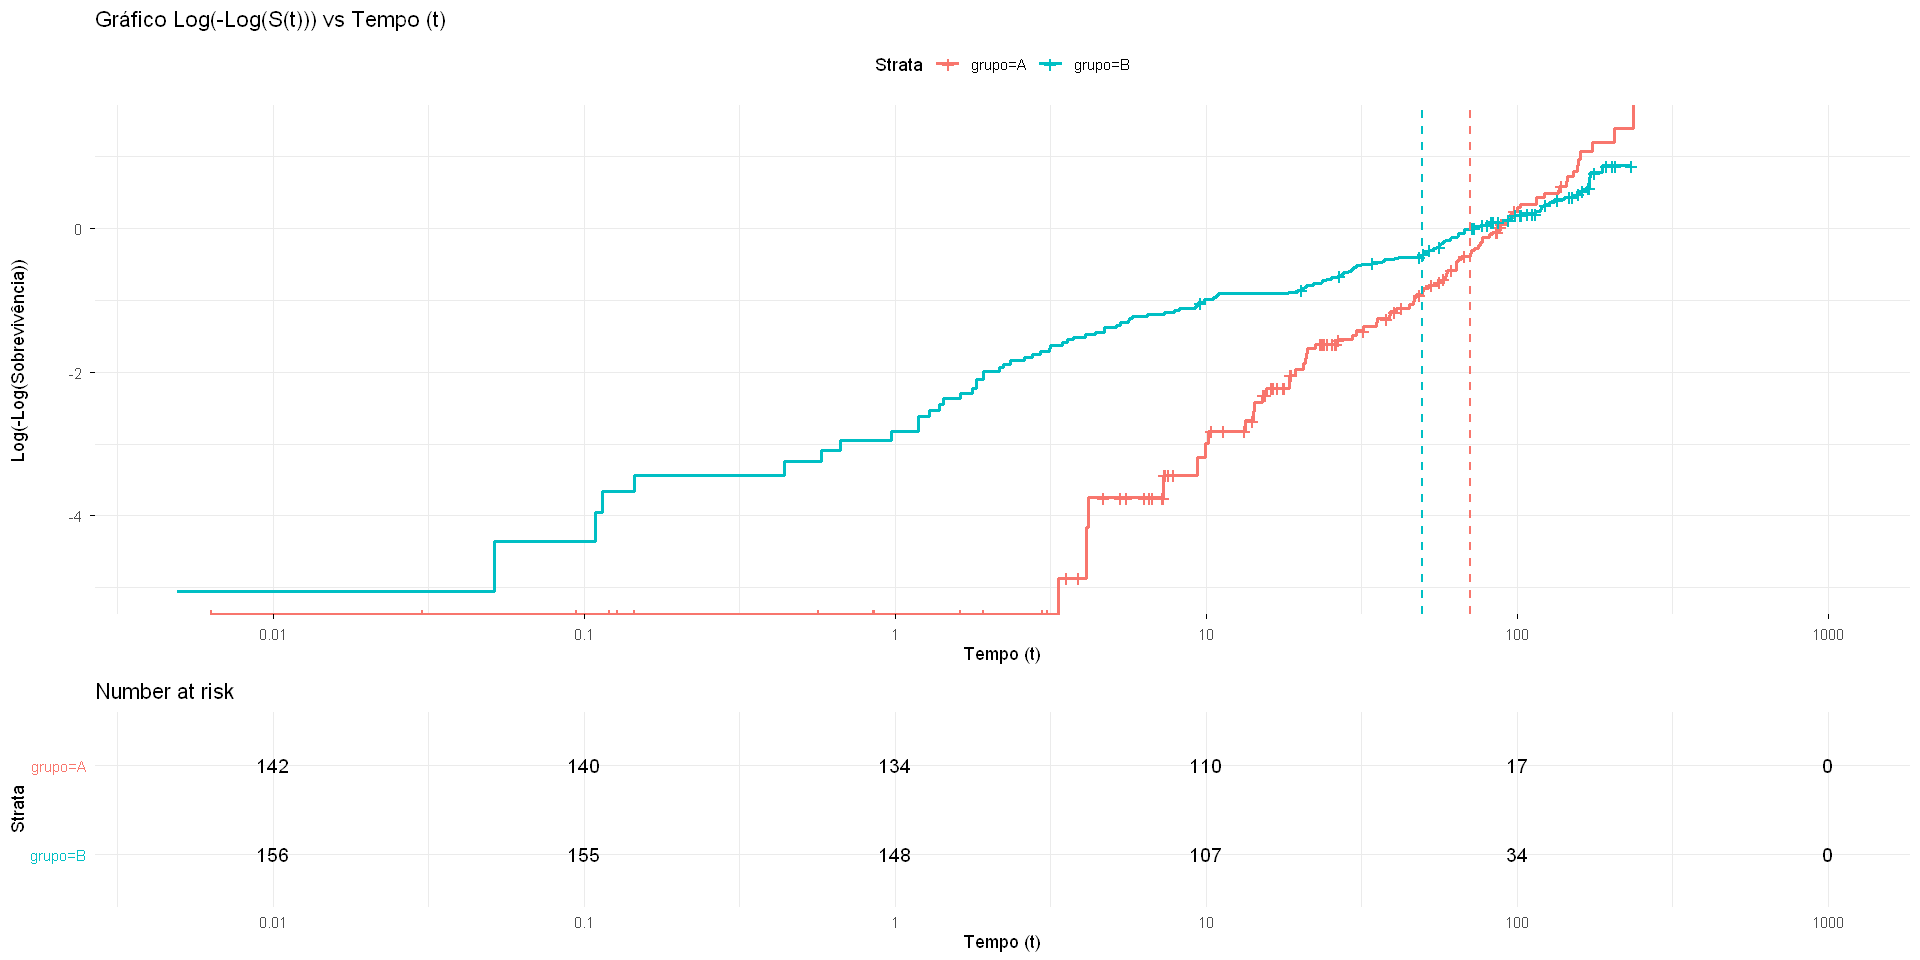

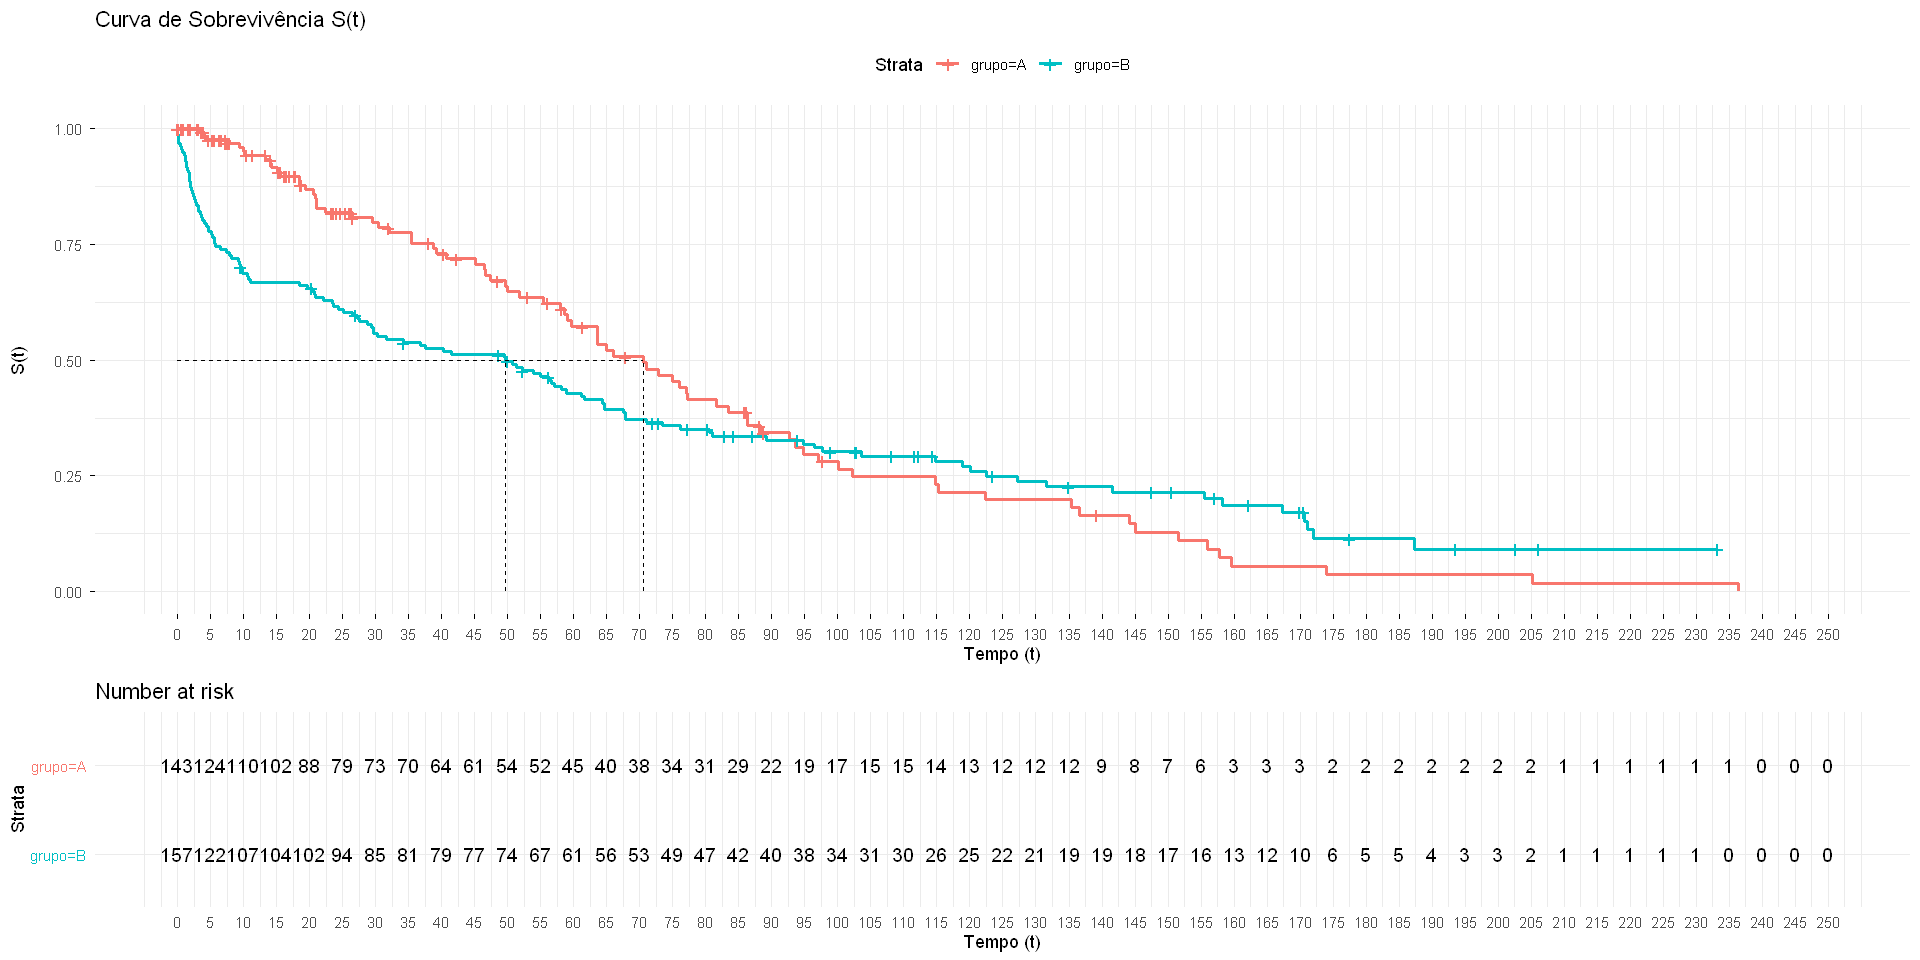

In [ ]:
medianas <- surv_median(curva)
print(medianas)

g <- ggsurvplot(curva, 
  conf.int = FALSE,
  risk.table = TRUE,
  risk.table.height = 0.3,
  fontsize = 4,
  break.time.by = 5,
  risk.table.y.text = TRUE,
  fun = "cloglog", 
  ggtheme = theme_minimal(),
  title = "Gráfico Log(-Log(S(t))) vs Log(t)",
  xlab = "Tempo Log(t)", 
  ylab = "Log(-Log(Sobrevivência))")

# adiciona uma linha vertical tracejada no tempo mediano de CADA grupo
g$plot <- g$plot + 
  geom_vline(data = medianas, aes(xintercept = median, color = strata),
             linetype = "dashed", linewidth = 0.6, show.legend = FALSE)

print(g)
ggsurvplot(
  curva,
  conf.int = FALSE,
  risk.table = TRUE,
  risk.table.height = 0.3,        # mais espaço vertical pra tabela
  fontsize = 4,                   # tamanho da fonte dentro da risk table
  break.time.by = 5,              # pontos de tempo mais proximos -- mais colunas na tabela
  surv.median.line = "hv",        # desenha a linha da mediana (horizontal ate a curva + vertical ate o eixo x)
  risk.table.y.text = TRUE,       # nomes dos grupos como texto (em vez de so cor)
  ggtheme = theme_minimal(),
  title = "Curva de Sobrevivência S(t)",
  xlab = "Tempo (t)",
  ylab = "S(t)"
)

In [6]:
library(dplyr)
surv_df <- data.frame(
  time   = curva$time,
  surv   = curva$surv,
  strata = rep(names(curva$strata), curva$strata)
)

df_A <- surv_df %>% filter(grepl("A", strata)) %>% select(time, surv)
df_B <- surv_df %>% filter(grepl("B", strata)) %>% select(time, surv)

sA <- stepfun(df_A$time, c(1, df_A$surv)) 
sB <- stepfun(df_B$time, c(1, df_B$surv))

grid <- seq(0, min(max(df_A$time), max(df_B$time)), length.out = 5000)

diff_S <- sA(grid) - sB(grid)
sinal <- sign(diff_S)
cruzamentos <- grid[which(diff(sinal) != 0)]

cruzamentos


Anexando pacote: 'dplyr'


O seguinte objeto é mascarado por 'package:Rlab':

    count


Os seguintes objetos são mascarados por 'package:stats':

    filter, lag


Os seguintes objetos são mascarados por 'package:base':

    intersect, setdiff, setequal, union




[1]  0.00000 13.38409

Processando n = 20 

=== Relatorio | n = 20 ===
Grupo Experimental (A) - Censura Media: 43.4%
Grupo Controle (B) - Censura Media: 21.7%
Processando n = 50 

=== Relatorio | n = 50 ===
Grupo Experimental (A) - Censura Media: 43.4%
Grupo Controle (B) - Censura Media: 21.6%
Processando n = 80 

=== Relatorio | n = 80 ===
Grupo Experimental (A) - Censura Media: 42.8%
Grupo Controle (B) - Censura Media: 21.7%
Processando n = 110 

=== Relatorio | n = 110 ===
Grupo Experimental (A) - Censura Media: 43.0%
Grupo Controle (B) - Censura Media: 22.2%
Processando n = 140 

=== Relatorio | n = 140 ===
Grupo Experimental (A) - Censura Media: 43.7%
Grupo Controle (B) - Censura Media: 21.2%
Processando n = 170 

=== Relatorio | n = 170 ===
Grupo Experimental (A) - Censura Media: 43.9%
Grupo Controle (B) - Censura Media: 21.5%
Processando n = 200 

=== Relatorio | n = 200 ===
Grupo Experimental (A) - Censura Media: 42.8%
Grupo Controle (B) - Censura Media: 21.4%
Processando n = 230 

=== Relatorio | n 

`geom_smooth()` using formula = 'y ~ x'


n,Poder,Teste
<dbl>,<dbl>,<fct>
20,0.050,"G(0,0)"
20,0.140,"G(1,0)"
20,0.065,"G(0,1)"
20,0.075,"G(1,1)"
50,0.060,"G(0,0)"
50,0.250,"G(1,0)"
50,0.170,"G(0,1)"
50,0.085,"G(1,1)"
80,0.095,"G(0,0)"


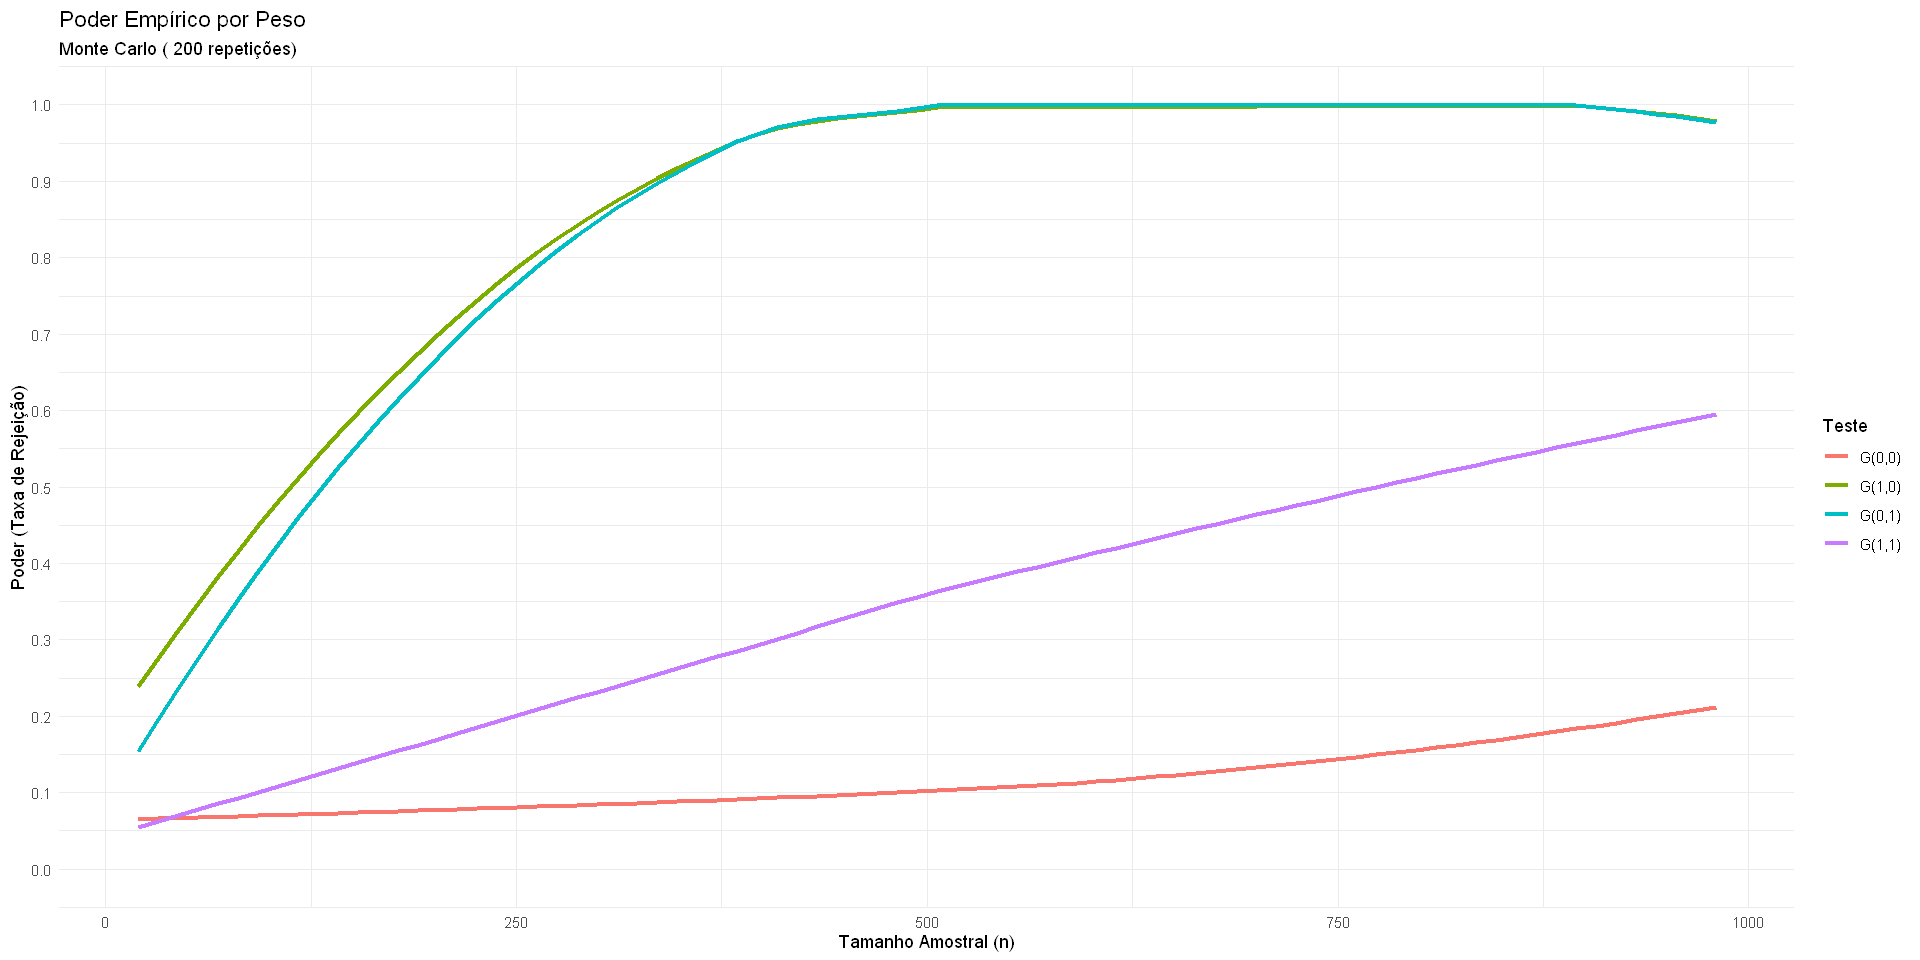

In [8]:
simulacao_amostral_empirica_4testes(n_sim = 200, 
                            ns = seq(20, 1000, by = 30),
                            alpha = 0.05) 


Processando n = 20 

=== Relatorio | n = 20 ===
Grupo Experimental (A) - Censura Media: 42.5%
Grupo Controle (B) - Censura Media: 22.8%
Processando n = 50 

=== Relatorio | n = 50 ===
Grupo Experimental (A) - Censura Media: 43.8%
Grupo Controle (B) - Censura Media: 22.2%
Processando n = 80 

=== Relatorio | n = 80 ===
Grupo Experimental (A) - Censura Media: 42.8%
Grupo Controle (B) - Censura Media: 21.8%
Processando n = 110 

=== Relatorio | n = 110 ===
Grupo Experimental (A) - Censura Media: 44.3%
Grupo Controle (B) - Censura Media: 22.3%
Processando n = 140 

=== Relatorio | n = 140 ===
Grupo Experimental (A) - Censura Media: 42.8%
Grupo Controle (B) - Censura Media: 21.7%
Processando n = 170 

=== Relatorio | n = 170 ===
Grupo Experimental (A) - Censura Media: 43.6%
Grupo Controle (B) - Censura Media: 22.2%
Processando n = 200 

=== Relatorio | n = 200 ===
Grupo Experimental (A) - Censura Media: 43.9%
Grupo Controle (B) - Censura Media: 21.9%
Processando n = 230 

=== Relatorio | n 

`geom_smooth()` using formula = 'y ~ x'


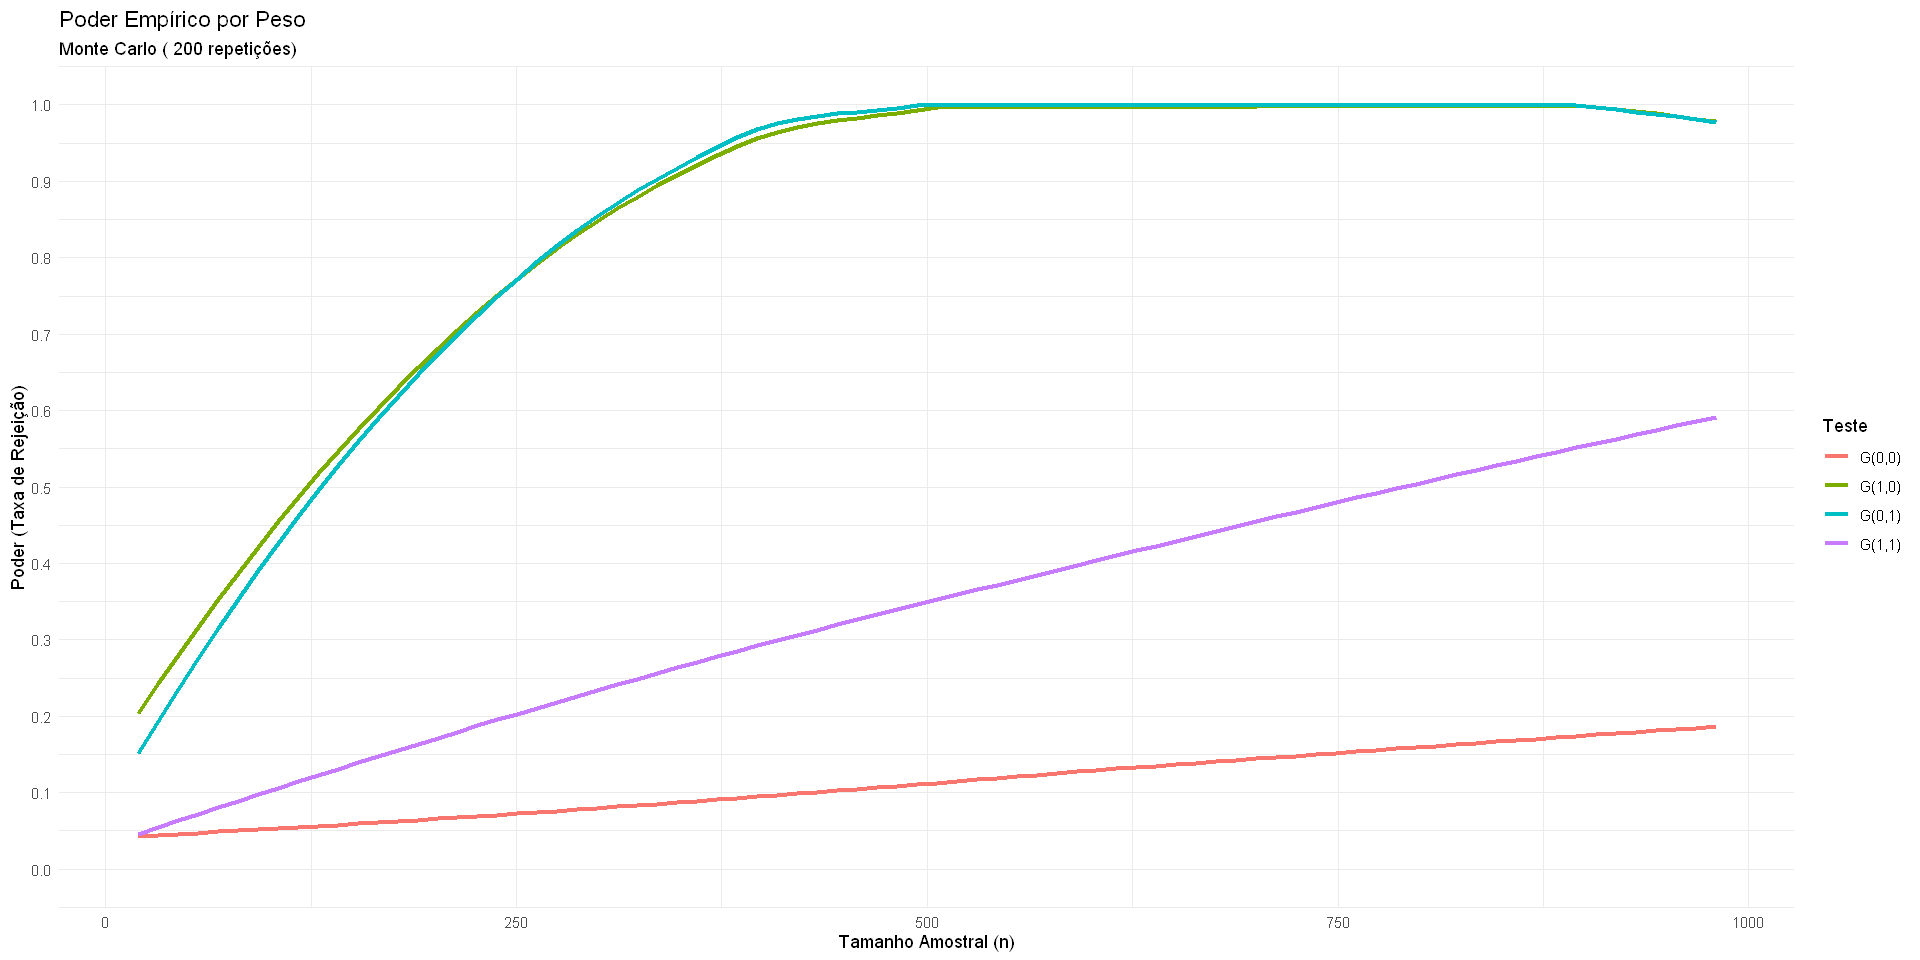

In [9]:
resultado_30 <- simulacao_amostral_empirica_4testes(n_sim = 200, 
                            ns = seq(20, 1000, by = 30),
                            alpha = 0.05) 

In [12]:
resultado_30 <- simulacao_amostral_empirica_4testes(n_sim = 200, 
                            ns = seq(20, 1000, by = 30),
                            alpha = 0.05) 

Processando n = 20 

=== Relatorio | n = 20 ===
Grupo Experimental (A) - Censura Media: 42.6%
Grupo Controle (B) - Censura Media: 21.8%
Processando n = 50 

=== Relatorio | n = 50 ===
Grupo Experimental (A) - Censura Media: 42.4%
Grupo Controle (B) - Censura Media: 21.9%
Processando n = 80 

=== Relatorio | n = 80 ===
Grupo Experimental (A) - Censura Media: 42.6%
Grupo Controle (B) - Censura Media: 22.4%
Processando n = 110 

=== Relatorio | n = 110 ===
Grupo Experimental (A) - Censura Media: 43.0%
Grupo Controle (B) - Censura Media: 21.8%
Processando n = 140 

=== Relatorio | n = 140 ===
Grupo Experimental (A) - Censura Media: 43.1%
Grupo Controle (B) - Censura Media: 21.8%
Processando n = 170 

=== Relatorio | n = 170 ===
Grupo Experimental (A) - Censura Media: 43.2%
Grupo Controle (B) - Censura Media: 21.5%
Processando n = 200 

=== Relatorio | n = 200 ===
Grupo Experimental (A) - Censura Media: 44.2%
Grupo Controle (B) - Censura Media: 21.7%
Processando n = 230 

=== Relatorio | n 

In [13]:
tabela <- with(resultado_30, tapply(Poder, list(n, Teste), identity))
print(round(tabela, 3))

    G(0,0) G(1,0) G(0,1) G(1,1)
20   0.055  0.130  0.095  0.065
50   0.060  0.300  0.200  0.070
80   0.050  0.380  0.335  0.105
110  0.060  0.460  0.505  0.115
140  0.040  0.605  0.575  0.135
170  0.095  0.645  0.610  0.155
200  0.075  0.775  0.715  0.155
230  0.040  0.805  0.835  0.155
260  0.080  0.830  0.870  0.215
290  0.065  0.915  0.895  0.205
320  0.075  0.930  0.940  0.240
350  0.085  0.935  0.945  0.210
380  0.100  0.925  0.975  0.300
410  0.135  0.980  0.965  0.345
440  0.140  0.970  0.990  0.340
470  0.140  0.990  0.980  0.310
500  0.105  0.995  0.995  0.345
530  0.110  0.990  0.990  0.365
560  0.085  0.995  1.000  0.335
590  0.120  1.000  0.995  0.360
620  0.155  1.000  1.000  0.435
650  0.130  1.000  1.000  0.425
680  0.200  0.995  1.000  0.430
710  0.140  1.000  1.000  0.495
740  0.145  1.000  1.000  0.445
770  0.180  1.000  1.000  0.465
800  0.140  1.000  1.000  0.555
830  0.105  1.000  1.000  0.530
860  0.170  1.000  1.000  0.505
890  0.145  1.000  1.000  0.565
920  0.1

`geom_smooth()` using formula = 'y ~ x'


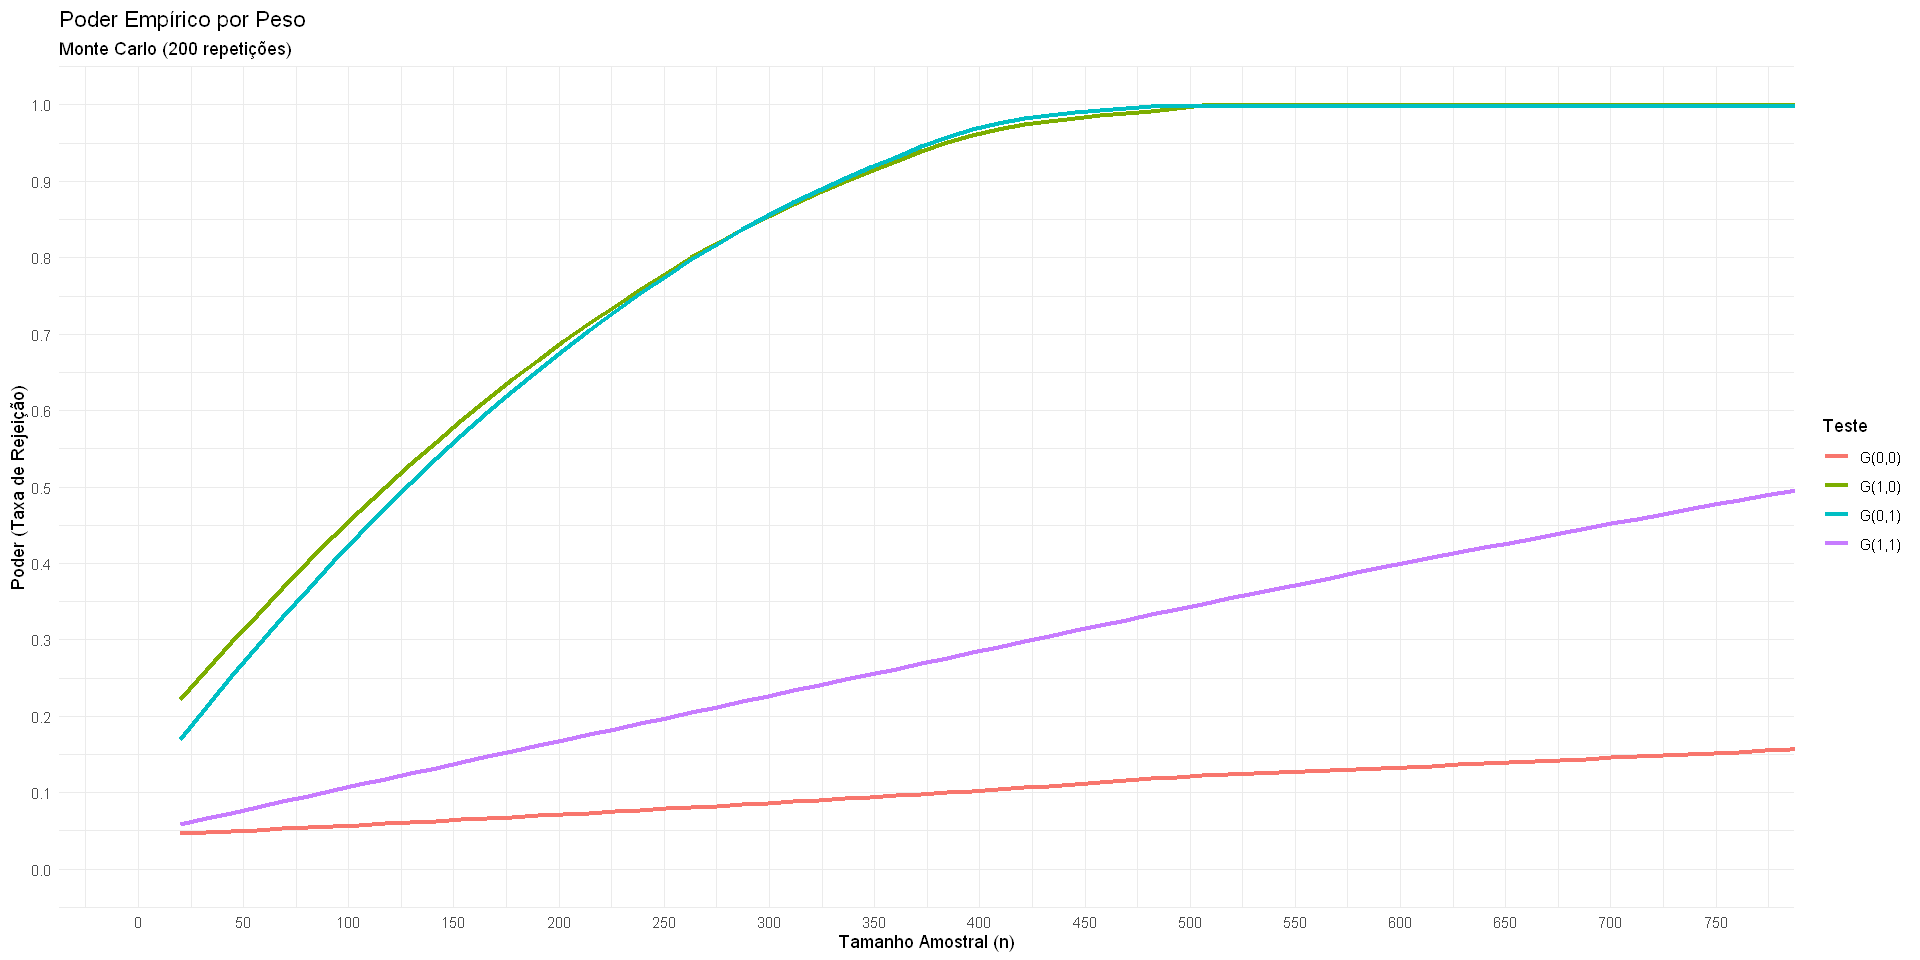

In [14]:
  g <- ggplot(resultado_30, aes(x = n, y = Poder, color = Teste)) +
    geom_smooth(method = "loess", se = FALSE, linewidth = 1.2, span = 1) +
    scale_y_continuous(limits = c(0, 1), breaks = seq(0, 1, 0.1)) +
     scale_x_continuous(breaks = seq(0, 900, by = 50)) +
     coord_cartesian(xlim = c(0, 750)) +
    labs(title = "Poder Empírico por Peso",
         subtitle = paste("Monte Carlo (200 repetições)"),
         x = "Tamanho Amostral (n)", y = "Poder (Taxa de Rejeição)") +
    theme_minimal()

  print(g)

Processando n = 20 

=== Relatorio | n = 20 ===
Grupo Experimental (A) - Censura Media: 42.7%
Grupo Controle (B) - Censura Media: 22.3%
Processando n = 40 

=== Relatorio | n = 40 ===
Grupo Experimental (A) - Censura Media: 42.5%
Grupo Controle (B) - Censura Media: 23.1%
Processando n = 60 

=== Relatorio | n = 60 ===
Grupo Experimental (A) - Censura Media: 43.5%
Grupo Controle (B) - Censura Media: 22.3%
Processando n = 80 

=== Relatorio | n = 80 ===
Grupo Experimental (A) - Censura Media: 43.1%
Grupo Controle (B) - Censura Media: 22.3%
Processando n = 100 

=== Relatorio | n = 100 ===
Grupo Experimental (A) - Censura Media: 43.4%
Grupo Controle (B) - Censura Media: 22.0%
Processando n = 120 

=== Relatorio | n = 120 ===
Grupo Experimental (A) - Censura Media: 43.5%
Grupo Controle (B) - Censura Media: 21.6%
Processando n = 140 

=== Relatorio | n = 140 ===
Grupo Experimental (A) - Censura Media: 44.3%
Grupo Controle (B) - Censura Media: 21.4%
Processando n = 160 

=== Relatorio | n = 

n,Poder,Teste
<dbl>,<dbl>,<fct>
20,0.060,"G(0,0)"
20,0.125,"G(1,0)"
20,0.130,"G(0,1)"
20,0.090,"G(1,1)"
40,0.085,"G(0,0)"
40,0.180,"G(1,0)"
40,0.200,"G(0,1)"
40,0.075,"G(1,1)"
60,0.070,"G(0,0)"


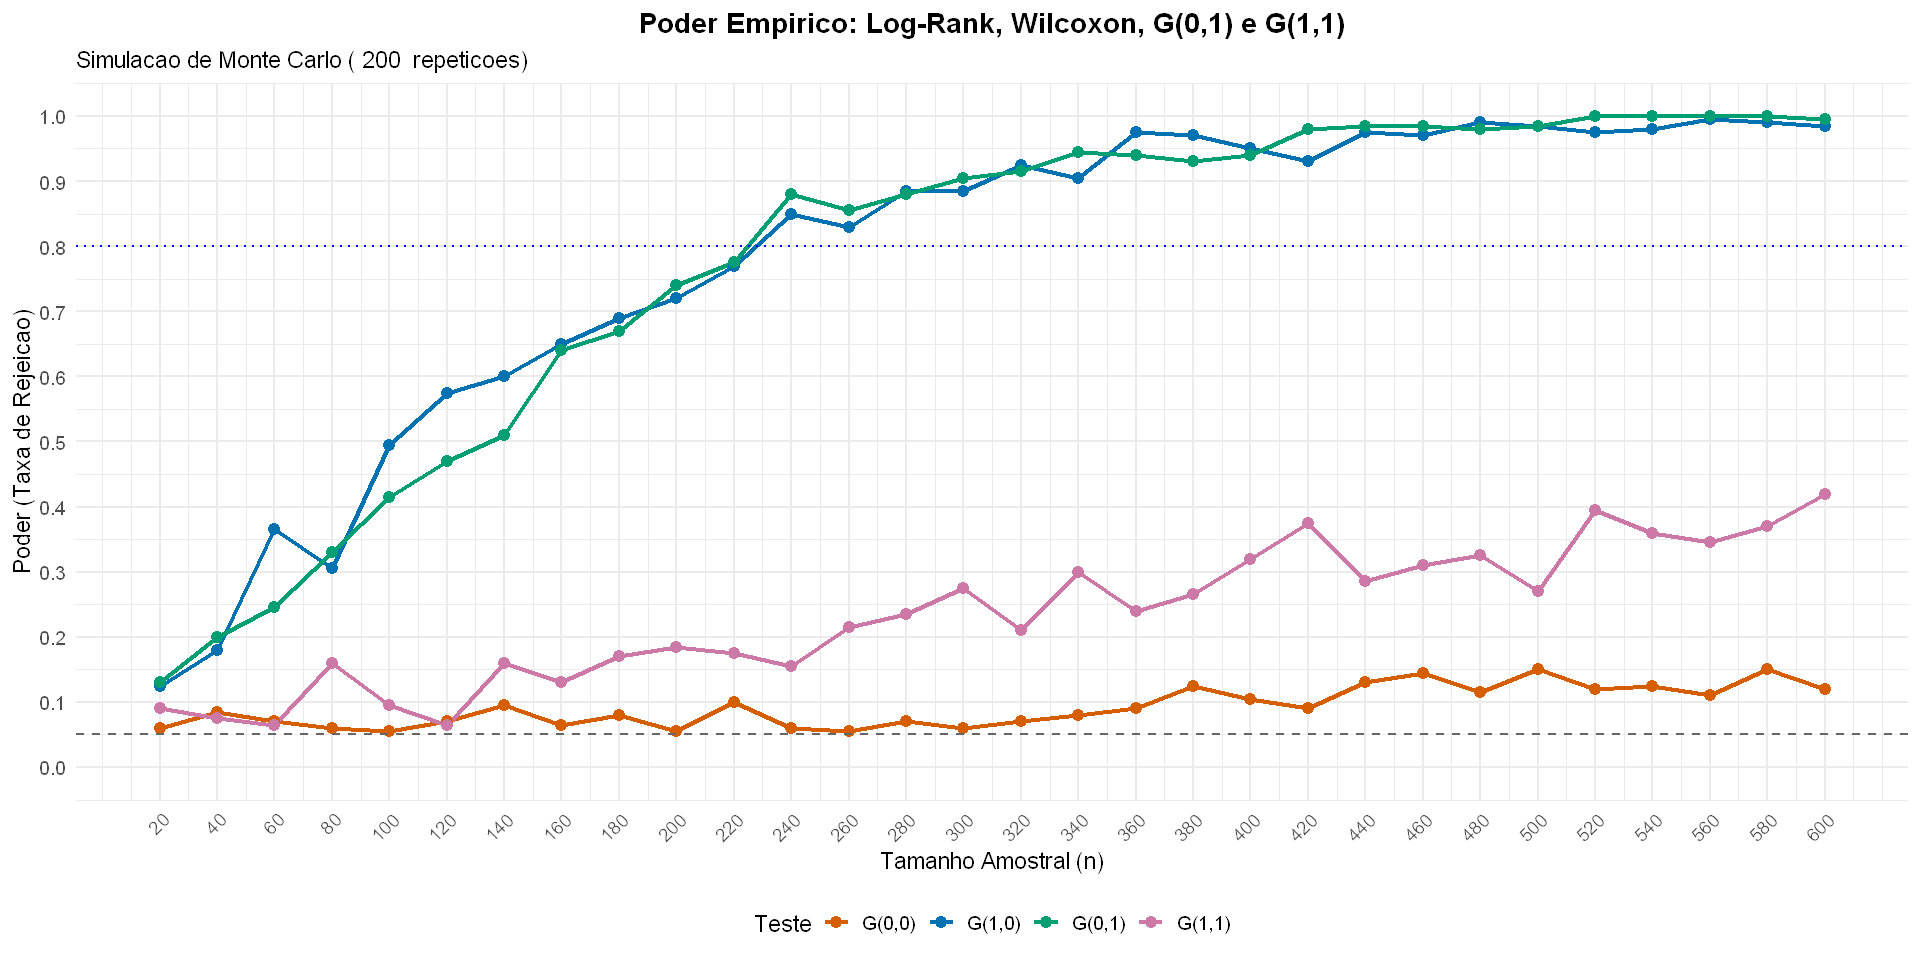

In [15]:
simulacao_amostral_empirica_4testes(n_sim = 200, 
                            ns = seq(20, 600, by = 20),
                            alpha = 0.05) 

In [14]:
resultado_0010 <- simulacao_amostral_empirica(n_sim = 200, 
                            ns = seq(20, 900, by = 30),
                            rho1 = 0, eta1 = 0,
                            rho2 = 1, eta2 = 0, 
                            alpha = 0.05) 

Processando n = 20 

=== Relatório | n = 20 ===
Grupo Experimental (A) - Censura Média: 43.0%
Grupo Controle (B) - Censura Média: 23.3%
Processando n = 50 

=== Relatório | n = 50 ===
Grupo Experimental (A) - Censura Média: 44.2%
Grupo Controle (B) - Censura Média: 21.2%
Processando n = 80 

=== Relatório | n = 80 ===
Grupo Experimental (A) - Censura Média: 43.5%
Grupo Controle (B) - Censura Média: 21.7%
Processando n = 110 

=== Relatório | n = 110 ===
Grupo Experimental (A) - Censura Média: 44.2%
Grupo Controle (B) - Censura Média: 21.2%
Processando n = 140 

=== Relatório | n = 140 ===
Grupo Experimental (A) - Censura Média: 43.7%
Grupo Controle (B) - Censura Média: 21.8%
Processando n = 170 

=== Relatório | n = 170 ===
Grupo Experimental (A) - Censura Média: 43.9%
Grupo Controle (B) - Censura Média: 21.9%
Processando n = 200 

=== Relatório | n = 200 ===
Grupo Experimental (A) - Censura Média: 43.4%
Grupo Controle (B) - Censura Média: 21.8%
Processando n = 230 

=== Relatório | n 

`geom_smooth()` using formula = 'y ~ x'


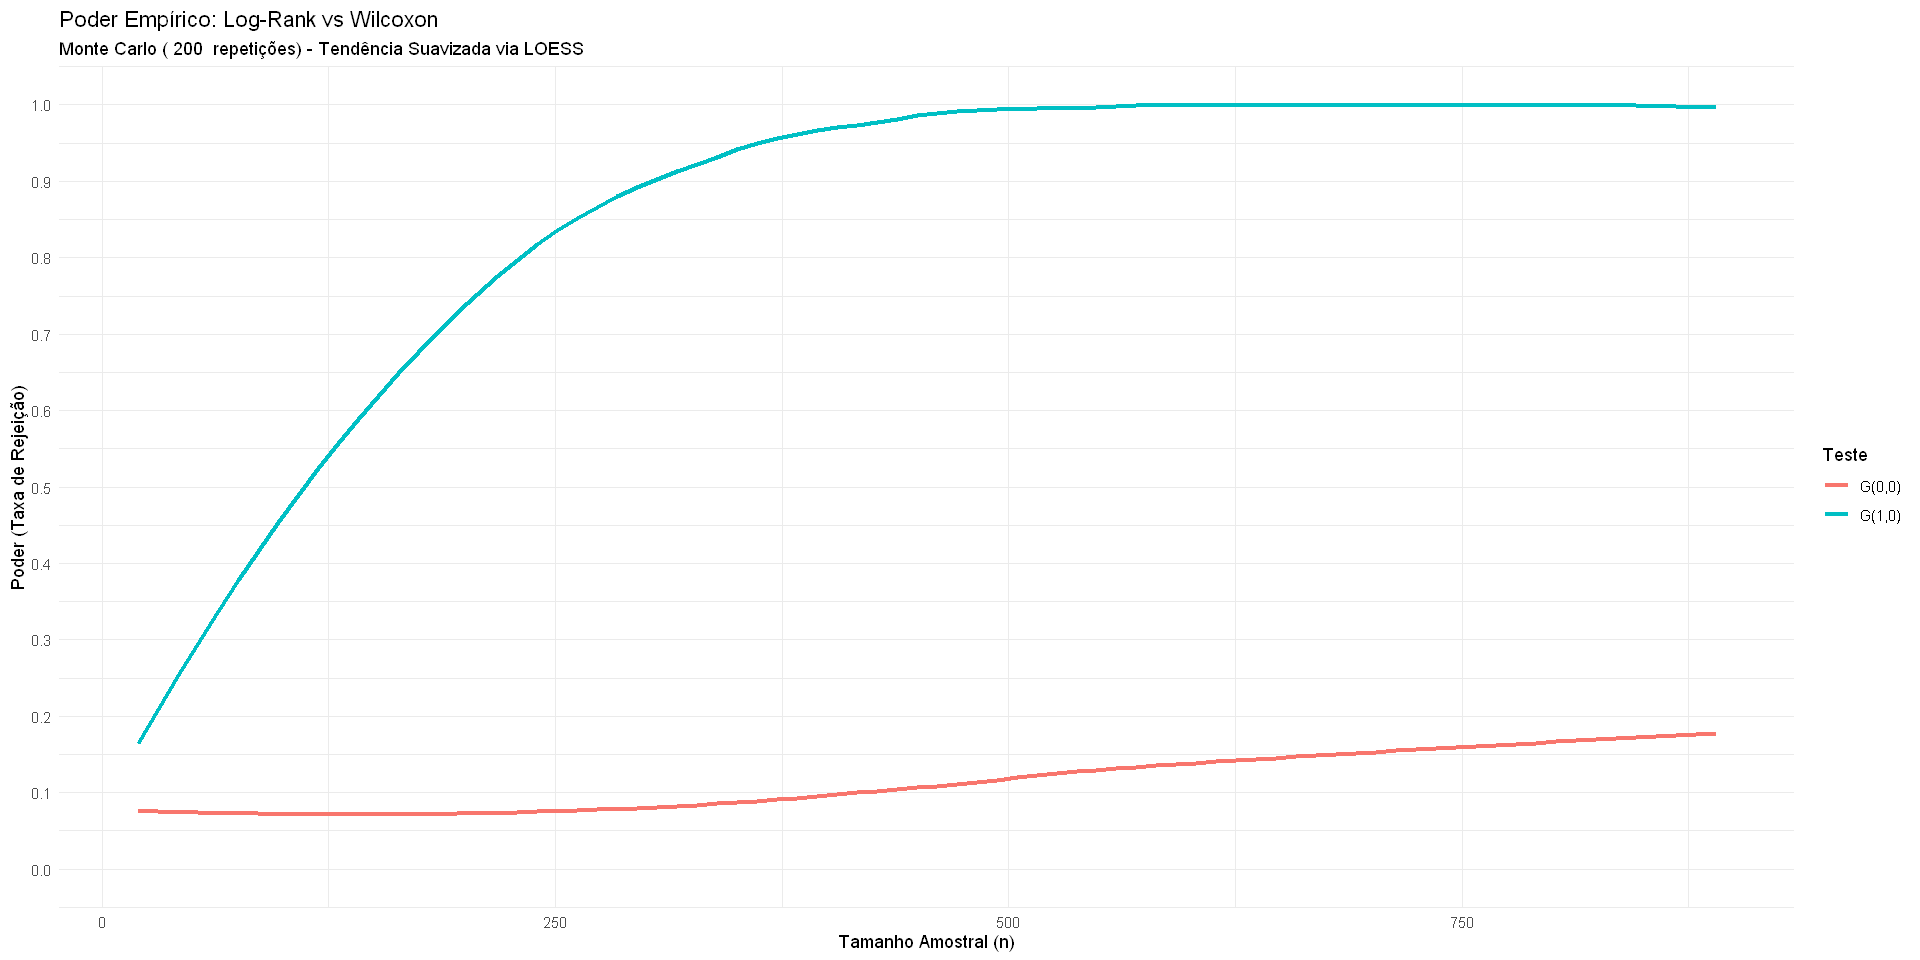

In [24]:
resultado_0010

In [15]:
resultado_0001 <- simulacao_amostral_empirica(n_sim = 200, 
                            ns = seq(20, 900, by = 30),
                            rho1 = 0, eta1 = 0,
                            rho2 = 0, eta2 = 1, 
                            alpha = 0.05) 

Processando n = 20 

=== Relatório | n = 20 ===
Grupo Experimental (A) - Censura Média: 42.6%
Grupo Controle (B) - Censura Média: 23.2%
Processando n = 50 

=== Relatório | n = 50 ===
Grupo Experimental (A) - Censura Média: 42.2%
Grupo Controle (B) - Censura Média: 21.8%
Processando n = 80 

=== Relatório | n = 80 ===
Grupo Experimental (A) - Censura Média: 43.0%
Grupo Controle (B) - Censura Média: 22.6%
Processando n = 110 

=== Relatório | n = 110 ===
Grupo Experimental (A) - Censura Média: 43.5%
Grupo Controle (B) - Censura Média: 22.2%
Processando n = 140 

=== Relatório | n = 140 ===
Grupo Experimental (A) - Censura Média: 44.0%
Grupo Controle (B) - Censura Média: 21.9%
Processando n = 170 

=== Relatório | n = 170 ===
Grupo Experimental (A) - Censura Média: 43.6%
Grupo Controle (B) - Censura Média: 21.6%
Processando n = 200 

=== Relatório | n = 200 ===
Grupo Experimental (A) - Censura Média: 43.7%
Grupo Controle (B) - Censura Média: 21.9%
Processando n = 230 

=== Relatório | n 

`geom_smooth()` using formula = 'y ~ x'


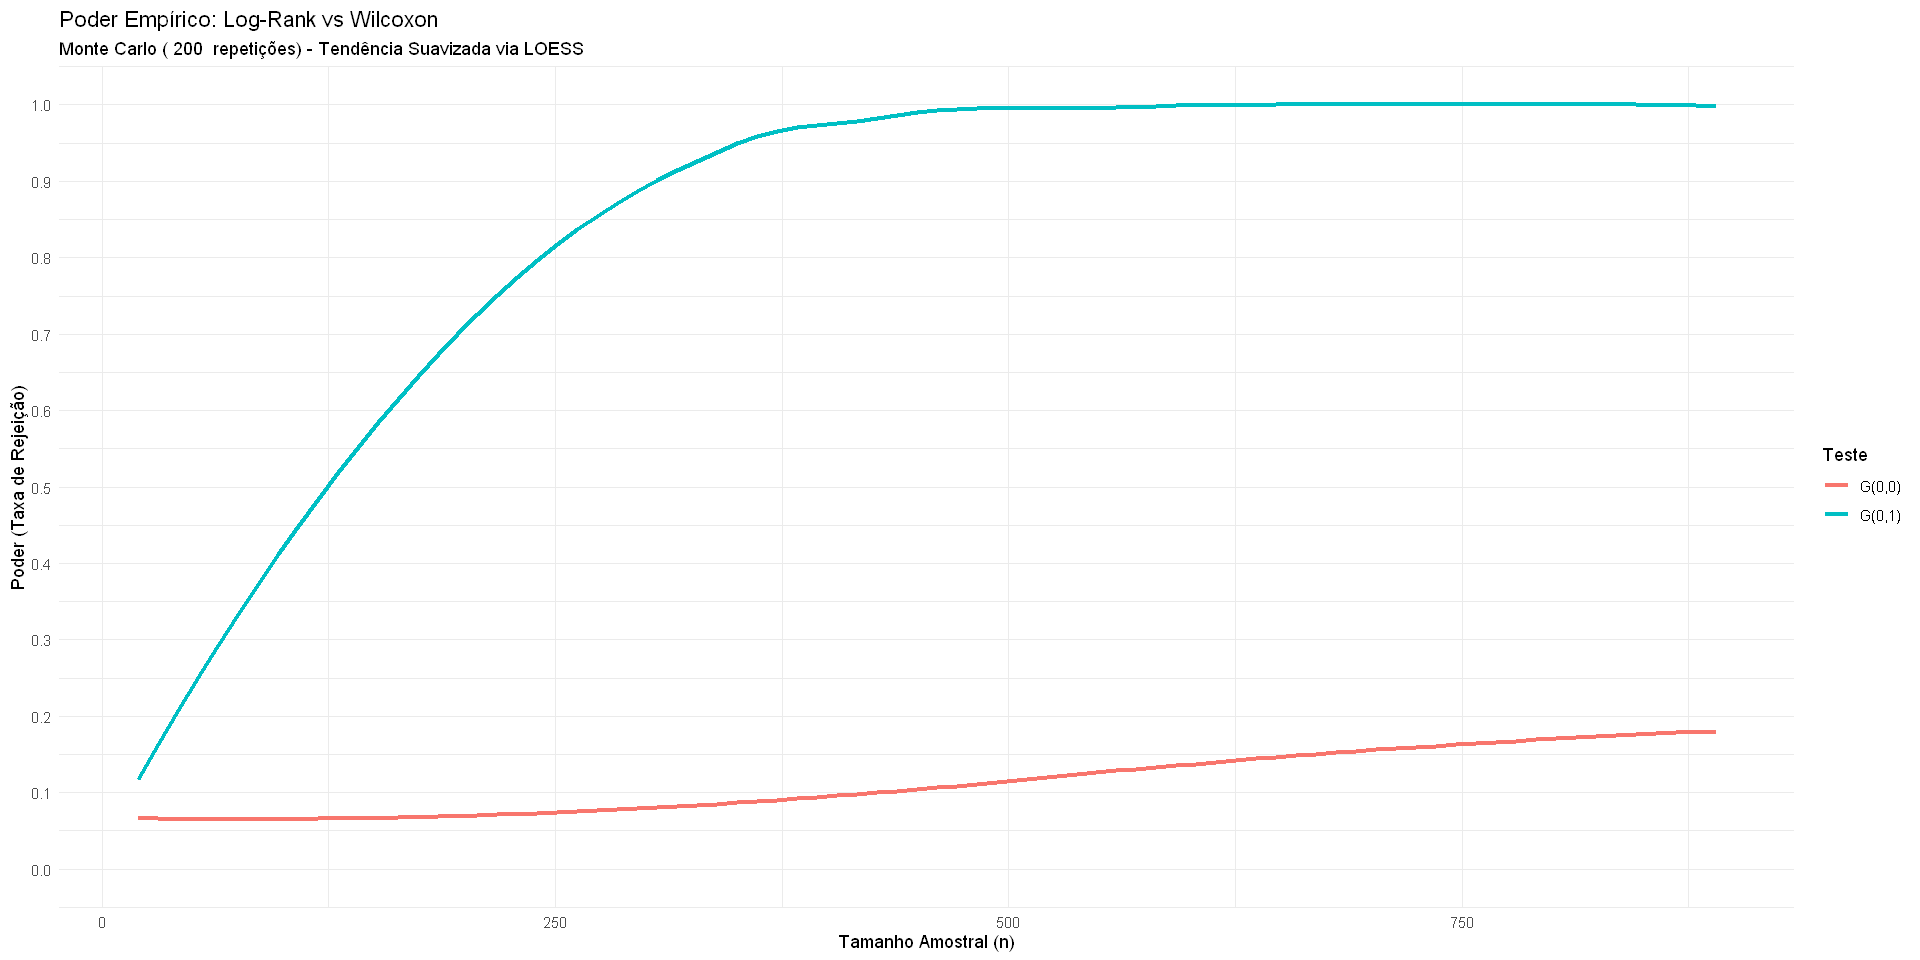

In [25]:
resultado_0001

In [16]:
resultado_1011 <- simulacao_amostral_empirica(n_sim = 200, 
                            ns = seq(20, 900, by = 30),
                            rho1 = 1, eta1 = 0,
                            rho2 = 1, eta2 = 1, 
                            alpha = 0.05) 

Processando n = 20 

=== Relatório | n = 20 ===
Grupo Experimental (A) - Censura Média: 43.8%
Grupo Controle (B) - Censura Média: 21.8%
Processando n = 50 

=== Relatório | n = 50 ===
Grupo Experimental (A) - Censura Média: 43.6%
Grupo Controle (B) - Censura Média: 22.9%
Processando n = 80 

=== Relatório | n = 80 ===
Grupo Experimental (A) - Censura Média: 44.2%
Grupo Controle (B) - Censura Média: 22.7%
Processando n = 110 

=== Relatório | n = 110 ===
Grupo Experimental (A) - Censura Média: 43.3%
Grupo Controle (B) - Censura Média: 21.6%
Processando n = 140 

=== Relatório | n = 140 ===
Grupo Experimental (A) - Censura Média: 43.0%
Grupo Controle (B) - Censura Média: 22.2%
Processando n = 170 

=== Relatório | n = 170 ===
Grupo Experimental (A) - Censura Média: 43.0%
Grupo Controle (B) - Censura Média: 21.6%
Processando n = 200 

=== Relatório | n = 200 ===
Grupo Experimental (A) - Censura Média: 43.9%
Grupo Controle (B) - Censura Média: 22.2%
Processando n = 230 

=== Relatório | n 

`geom_smooth()` using formula = 'y ~ x'


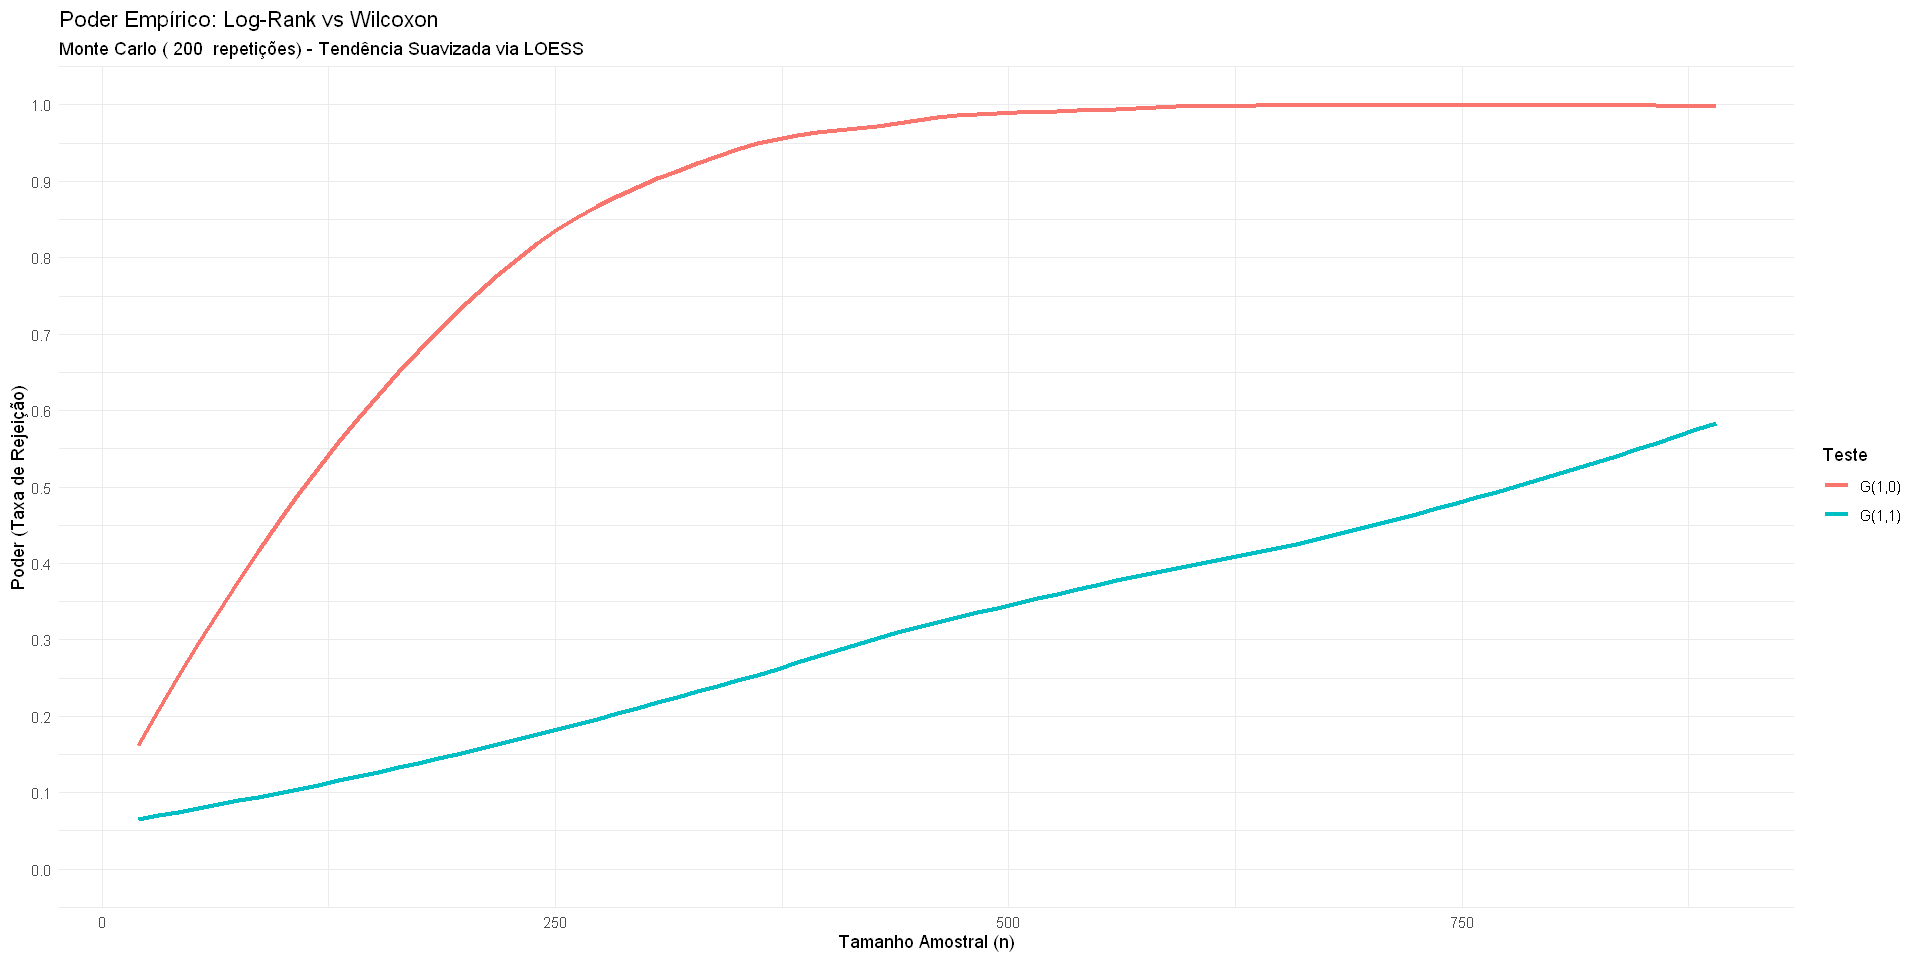

In [26]:
resultado_1011

In [17]:
resultado_0011 <- simulacao_amostral_empirica(n_sim = 200, 
                            ns = seq(20, 900, by = 30),
                            rho1 = 0, eta1 = 0,
                            rho2 = 1, eta2 = 1, 
                            alpha = 0.05) 

Processando n = 20 

=== Relatório | n = 20 ===
Grupo Experimental (A) - Censura Média: 43.1%
Grupo Controle (B) - Censura Média: 21.8%
Processando n = 50 

=== Relatório | n = 50 ===
Grupo Experimental (A) - Censura Média: 43.9%
Grupo Controle (B) - Censura Média: 22.2%
Processando n = 80 

=== Relatório | n = 80 ===
Grupo Experimental (A) - Censura Média: 43.5%
Grupo Controle (B) - Censura Média: 22.2%
Processando n = 110 

=== Relatório | n = 110 ===
Grupo Experimental (A) - Censura Média: 43.3%
Grupo Controle (B) - Censura Média: 20.6%
Processando n = 140 

=== Relatório | n = 140 ===
Grupo Experimental (A) - Censura Média: 44.4%
Grupo Controle (B) - Censura Média: 22.0%
Processando n = 170 

=== Relatório | n = 170 ===
Grupo Experimental (A) - Censura Média: 42.9%
Grupo Controle (B) - Censura Média: 21.3%
Processando n = 200 

=== Relatório | n = 200 ===
Grupo Experimental (A) - Censura Média: 42.7%
Grupo Controle (B) - Censura Média: 21.0%
Processando n = 230 

=== Relatório | n 

`geom_smooth()` using formula = 'y ~ x'


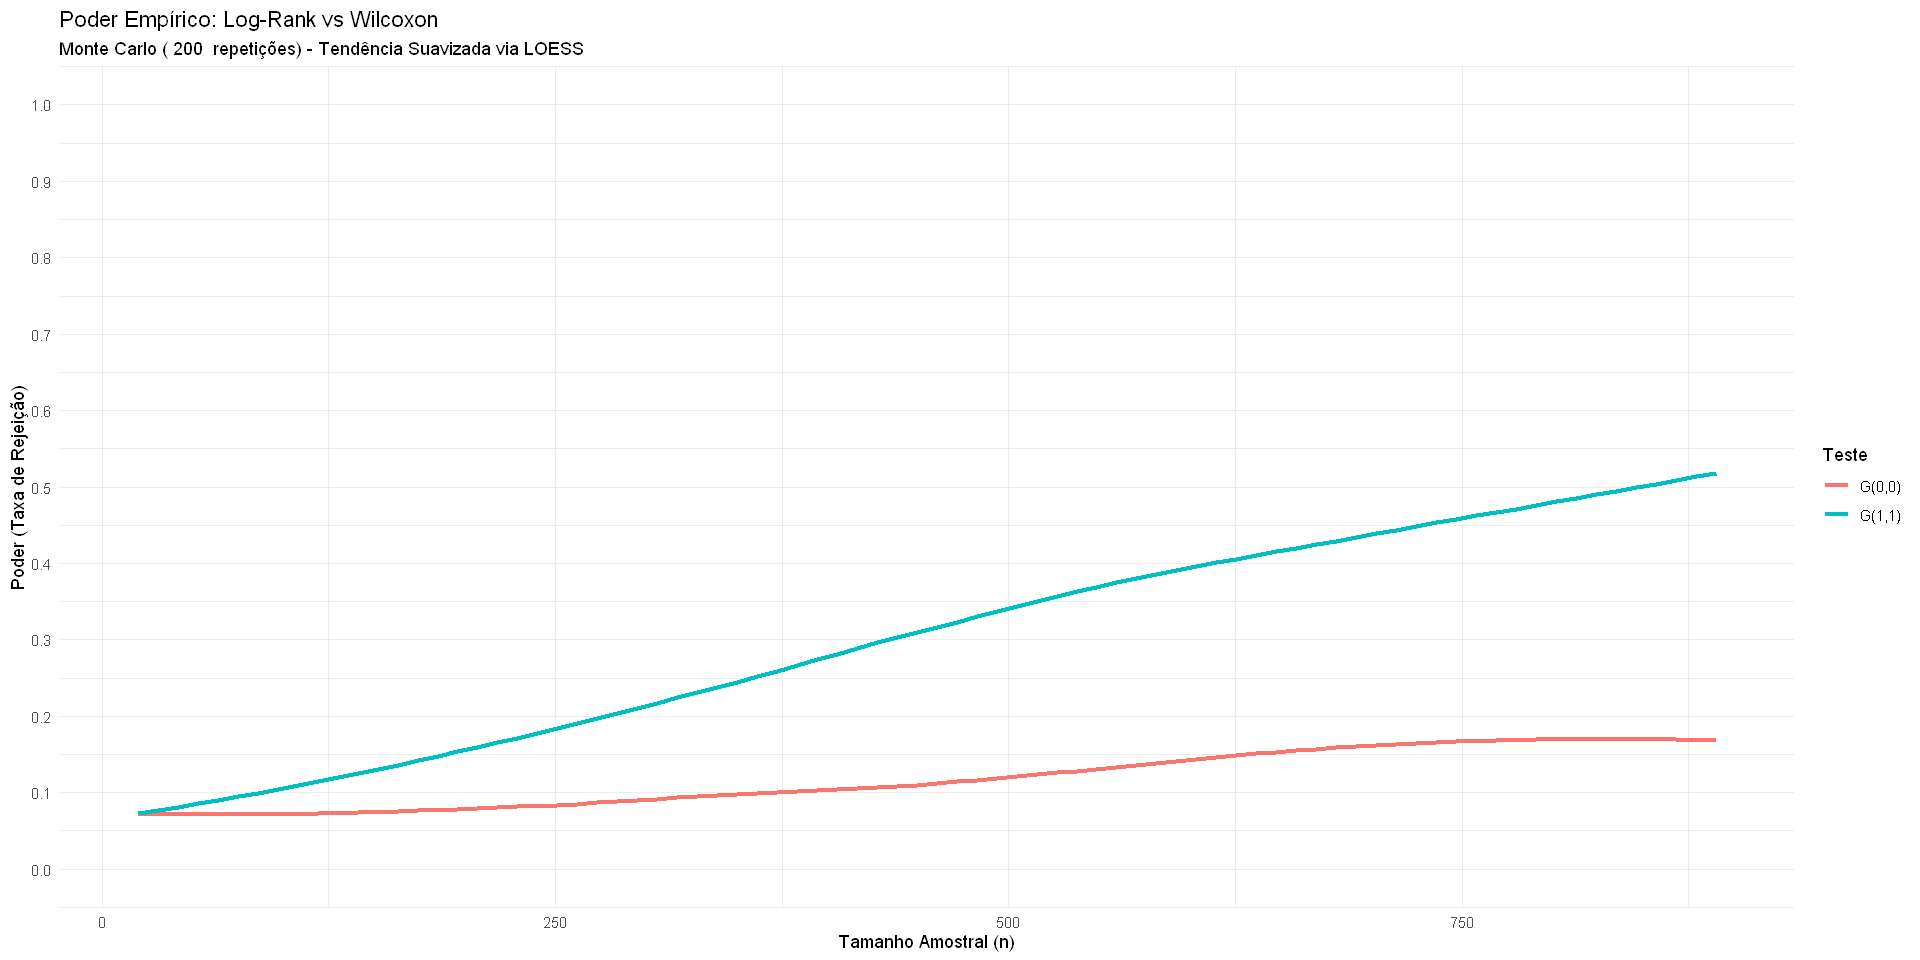

In [27]:
resultado_0011

In [18]:
resultado_1001 <- simulacao_amostral_empirica(n_sim = 200, 
                            ns = seq(20, 900, by = 30),
                            rho1 = 1, eta1 = 0,
                            rho2 = 0, eta2 = 1, 
                            alpha = 0.05) 

Processando n = 20 

=== Relatório | n = 20 ===
Grupo Experimental (A) - Censura Média: 41.4%
Grupo Controle (B) - Censura Média: 22.9%
Processando n = 50 

=== Relatório | n = 50 ===
Grupo Experimental (A) - Censura Média: 44.7%
Grupo Controle (B) - Censura Média: 21.4%
Processando n = 80 

=== Relatório | n = 80 ===
Grupo Experimental (A) - Censura Média: 44.3%
Grupo Controle (B) - Censura Média: 21.7%
Processando n = 110 

=== Relatório | n = 110 ===
Grupo Experimental (A) - Censura Média: 43.2%
Grupo Controle (B) - Censura Média: 22.2%
Processando n = 140 

=== Relatório | n = 140 ===
Grupo Experimental (A) - Censura Média: 43.2%
Grupo Controle (B) - Censura Média: 21.7%
Processando n = 170 

=== Relatório | n = 170 ===
Grupo Experimental (A) - Censura Média: 43.8%
Grupo Controle (B) - Censura Média: 21.6%
Processando n = 200 

=== Relatório | n = 200 ===
Grupo Experimental (A) - Censura Média: 44.0%
Grupo Controle (B) - Censura Média: 21.8%
Processando n = 230 

=== Relatório | n 

`geom_smooth()` using formula = 'y ~ x'


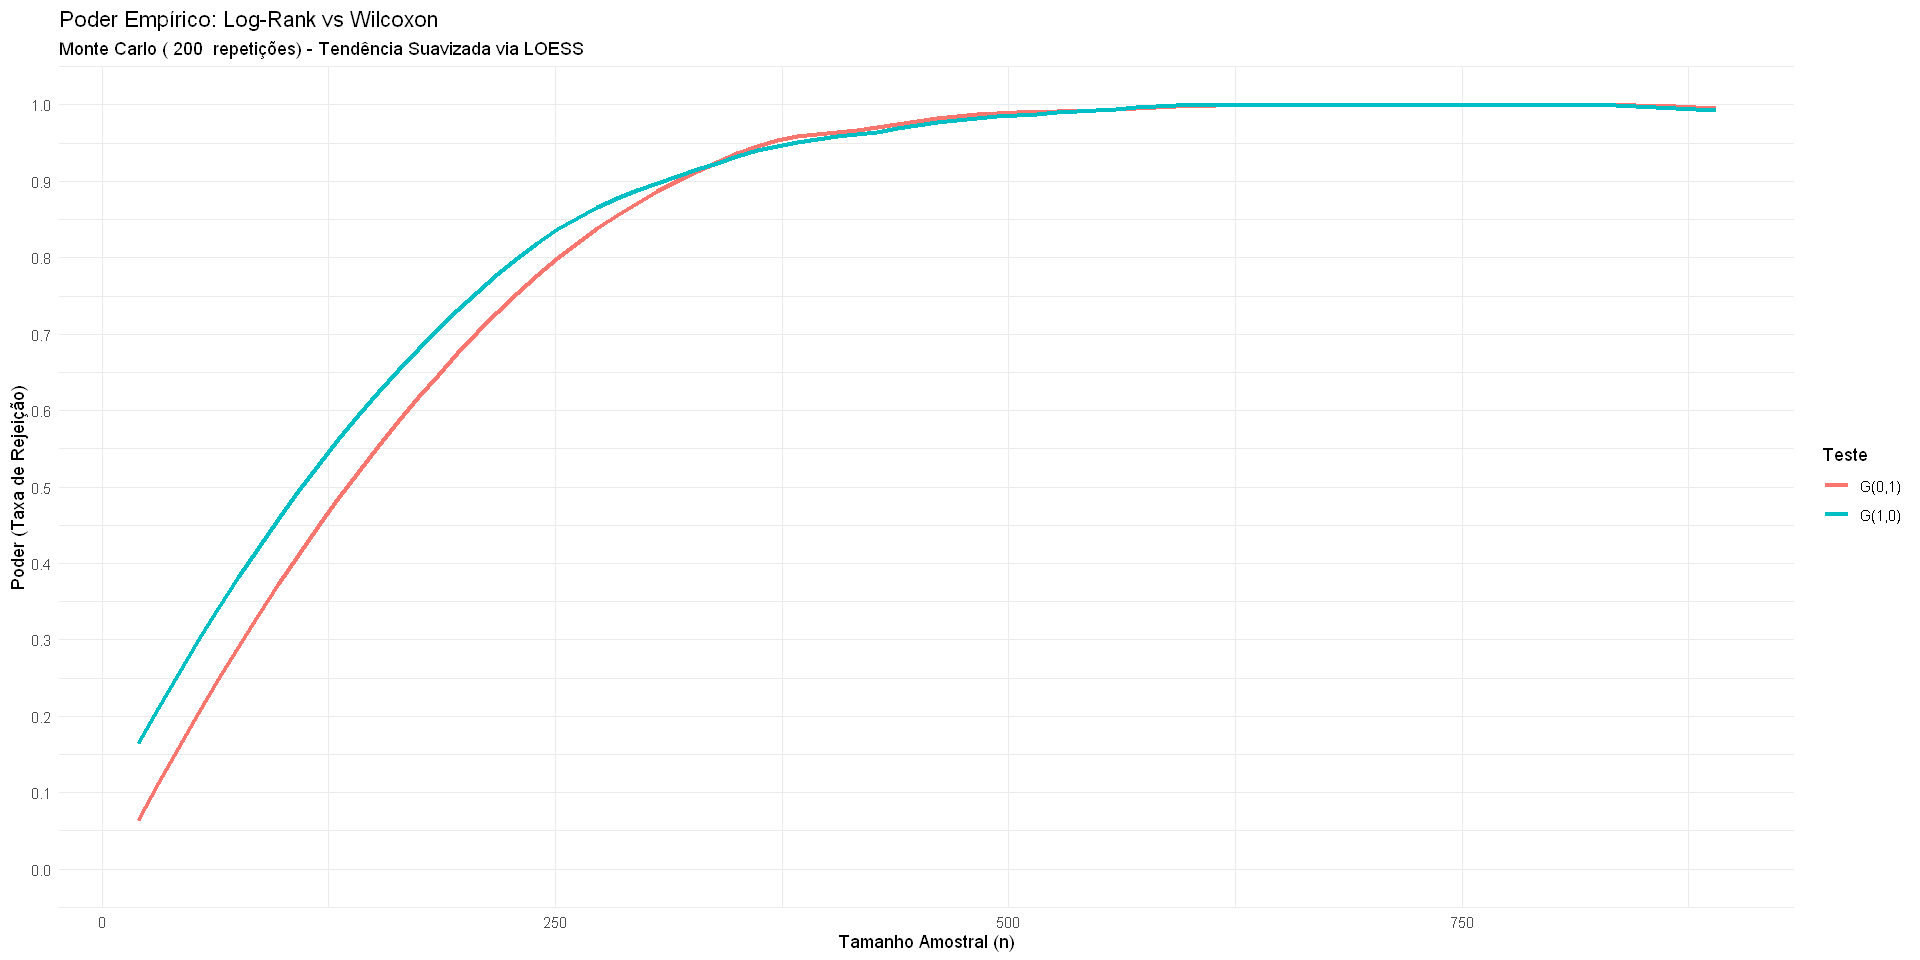

In [28]:
resultado_1001


=== Resumo de Eventos por Intervalo de Tempo (Quantis) ===
       Intervalo Individuos_Totais Falhas Censuras Taxa_Censura_Pct
        0 a 2.12             19778  10532     9246            46.7%
     2.12 a 7.73             19778  12382     7396            37.4%
    7.73 a 16.45             19778  13509     6269            31.7%
   16.45 a 27.75             19777  14471     5306            26.8%
   27.75 a 42.26             19778  15035     4743              24%
   42.26 a 60.74             19778  15282     4496            22.7%
   60.74 a 86.07             19777  15089     4688            23.7%
  86.07 a 126.89             19778  13704     6074            30.7%
 126.89 a 441.51             19778   9552    10226            51.7%



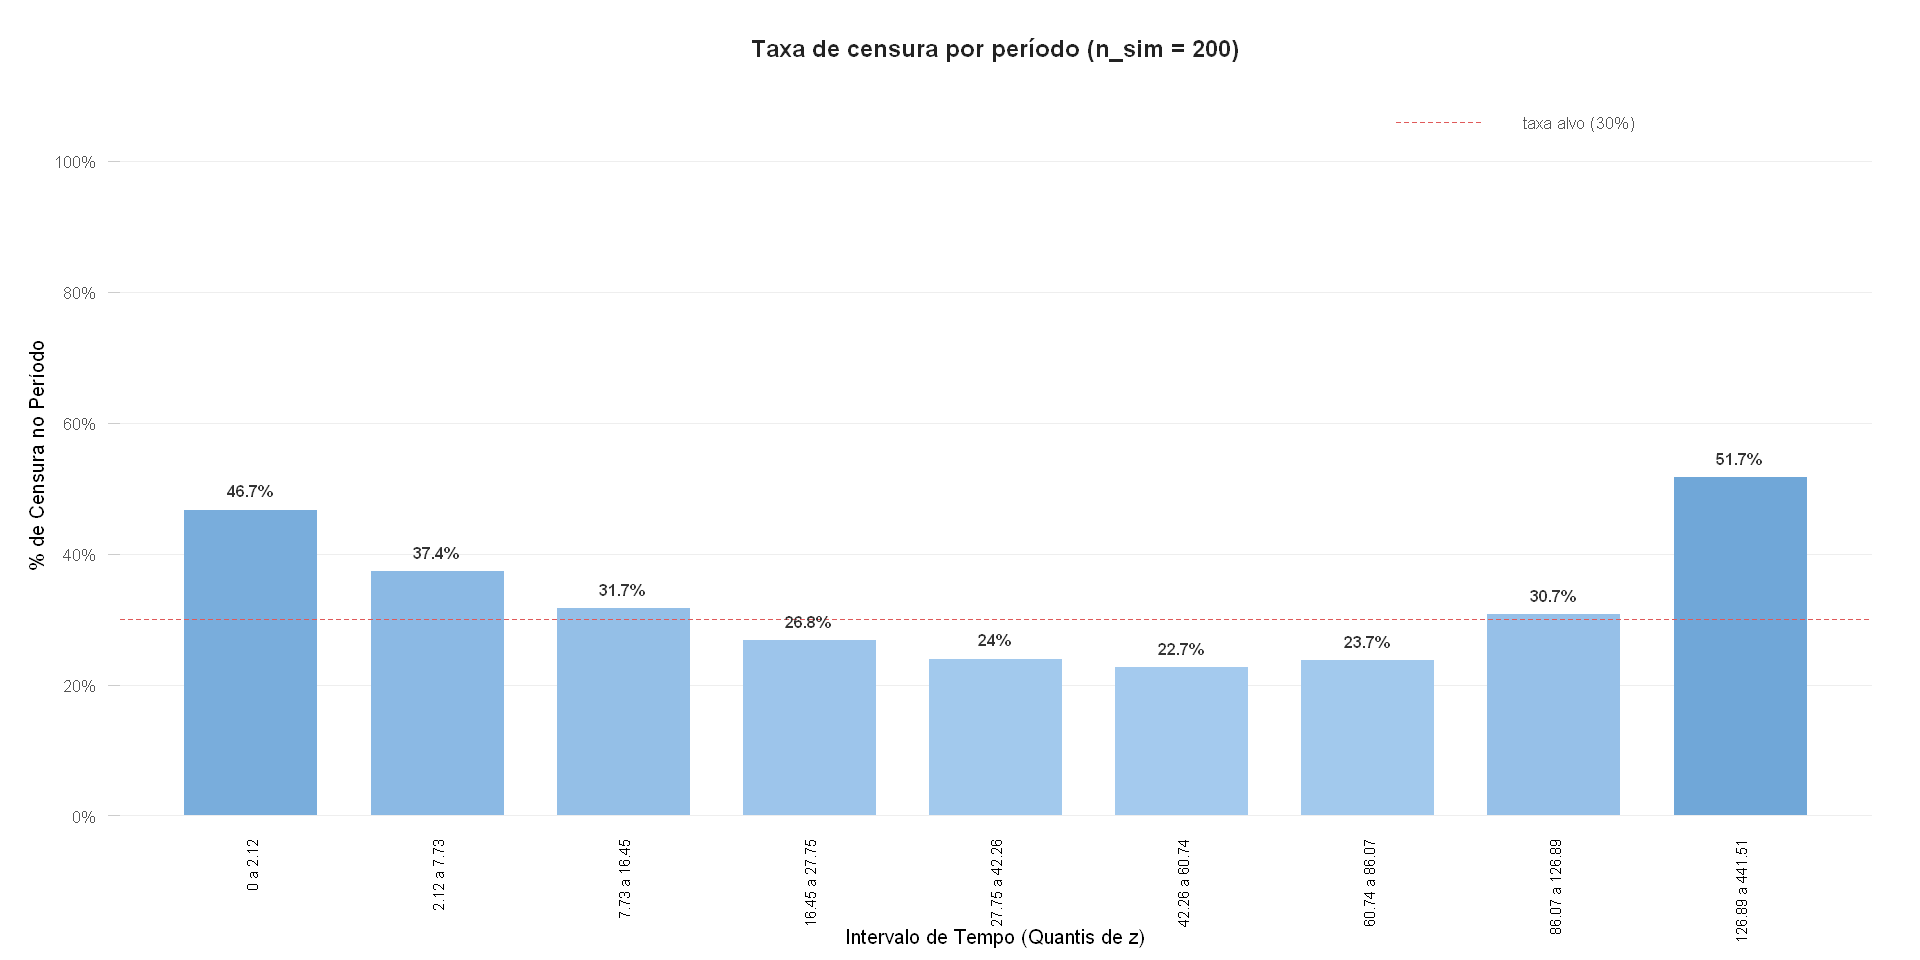

In [29]:
avaliar_perfil_censura_independente(
  n_sim = 200)